# GPM Rainfall as an Auxiliary AQI Predictor
## Trivariate Study: MODIS AOD × Ground-Truth AQI × GPM IMERG Rainfall

This notebook investigates whether GPM precipitation data can **complement or partially substitute** MODIS AOD for AQI prediction, motivated by the observation that RANSAC regression of AOD vs AQI shows poor correlation.

### Research questions
1. What does the GPM rainfall distribution look like at station level, and when do rain events occur?
2. How well does GPM correlate with AQI and AOD individually (Spearman + RANSAC)?
3. Does AOD→AQI RANSAC leave systematic residuals that GPM can explain?
4. What is the optimal rain-to-AQI/AOD lag?
5. Does GPM significantly improve AQI prediction beyond AOD alone (Δ R², partial R², Random Forest importance)?


## 1. Imports & Configuration

In [1]:
import os, re, glob, zipfile, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu

from sklearn.linear_model import LinearRegression, RANSACRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10


In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
MODIS_AQI_DIR = "/home/slow_data/Air_Quality/MODIS_MCD19A2/stations_aod_v2/"
STATION_META  = "/home/slow_data/Air_Quality/Envisoft_station_metadata.csv"
GIS_ROOT      = "/home/slow_data/Air_Quality/GIS/station_gis_extracted"

# ── Constants ──────────────────────────────────────────────────────────────
AOD_COLS    = ["Optical_Depth_047", "Optical_Depth_055"]
GPM_NODATA  = 29999
GPM_SCALE   = 0.1      # raw integer → mm / 30 min
MIN_OBS     = 5        # minimum matched records per station


## 2. Load MODIS AOD + AQI Data

In [3]:
csv_files = sorted(glob.glob(os.path.join(MODIS_AQI_DIR, "MODIS_AQI_*.csv")))
print(f"Found {len(csv_files)} station CSV files")

dfs = []
for f in csv_files:
    m = re.search(r'MODIS_AQI_(.+)\.csv', os.path.basename(f))
    station_id = m.group(1) if m else os.path.basename(f)
    tmp = pd.read_csv(f, parse_dates=['timestamp'])
    tmp['station_id'] = station_id
    dfs.append(tmp)

df_modis = pd.concat(dfs, ignore_index=True)
df_modis['AQI']  = pd.to_numeric(df_modis['AQI'], errors='coerce')
df_modis['date'] = df_modis['timestamp'].dt.normalize()

print(f"MODIS dataset: {len(df_modis):,} rows, {df_modis['station_id'].nunique()} stations")
df_modis.head()


Found 13 station CSV files
MODIS dataset: 8,075 rows, 13 stations


,ID,timestamp,Timestamp_MODIS_str,Optical_Depth_047,Optical_Depth_055,AOD_Uncertainty,Column_WV,AngstromExp_470-780,AOD_QA,FineModeFraction,...,NO2,O3,SO2,Temperature,Humidity,Pressure,Wind Speed,Timestamp_DT,station_id,date
0,28505268571336961948594948504,2022-09-03 10:45:00,20220903_1045,0.55775,0.424250,0.0391,5.968,NaN,1283.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28505268571336961948594948504,2022-09-03
1,28505268571336961948594948504,2022-09-03 13:40:00,20220903_1340,0.09700,0.072000,0.0413,4.765,NaN,1089.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28505268571336961948594948504,2022-09-03
2,28505268571336961948594948504,2022-09-05 13:25:00,20220905_1325,0.00200,0.001000,0.1235,4.401,NaN,1.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28505268571336961948594948504,2022-09-05
3,28505268571336961948594948504,2022-09-06 14:10:00,20220906_1410,0.27500,0.207000,0.0147,3.476,NaN,1057.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28505268571336961948594948504,2022-09-06
4,28505268571336961948594948504,2022-09-07 10:20:00,20220907_1020,0.51900,0.393667,0.0490,5.495,NaN,1282.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28505268571336961948594948504,2022-09-07


## 3. Load Station Metadata (Lat / Lon)

In [4]:
meta = pd.read_csv(STATION_META)
col_map = {c.lower(): c for c in meta.columns}
lat_col = col_map.get('latitude', col_map.get('lat'))
lon_col = col_map.get('longitude', col_map.get('lon'))
id_col  = col_map.get('station_id', col_map.get('id', meta.columns[0]))

meta_coords = meta[[id_col, lat_col, lon_col]].copy()
meta_coords.columns = ['station_id', 'lat', 'lon']
meta_coords['station_id'] = meta_coords['station_id'].astype(str)
print(f"Coordinates available for {len(meta_coords)} stations")
meta_coords.head()


Coordinates available for 13 stations


,station_id,lat,lon
Bình Dương: số 593 Đại lộ Bình Dương,31388839920718814259329251882,10.99230,106.6577
Bắc Giang: Khu liên cơ quan tỉnh Bắc Giang - P. Ngô Quyền - TP. Bắc Giang (KK),21.3015,106.22603,NaN
HCM: Khu Liên cơ quan Bộ Tài Nguyên và Môi Trường - số 20 Đ. Lý Chính Thắng (KK),10.7823,106.68340,NaN
HCM: Đ. Lê Hữu Kiều - P. Bình Trưng Tây - Quận 2 (Ngã ba Lê Hữu Kiểu và Trương Văn Bang) (KK),10.7823,106.75280,NaN
Hà Nam: Công Viên Nam Cao - P.Quang Trung - TP. Phủ Lý (KK),20.536,105.91650,NaN


## 4. Load GPM IMERG Data

GPM half-hourly (30-min) tiles were extracted at each station location and stored as CSVs under  
`GIS_ROOT`. We aggregate to **daily totals (mm/day)** and also retain useful sub-daily statistics.


In [5]:
csv_files = sorted(glob.glob(os.path.join(GIS_ROOT, "*.csv")))
print(f"Found {len(csv_files)} GPM station CSV files")

dfs = []
for f in csv_files:
    station_id = os.path.basename(f)[:-4]
    tmp = pd.read_csv(f, parse_dates=['timestamp'])
    tmp['station_id'] = station_id
    dfs.append(tmp)

df_gpm_raw = pd.concat(dfs, ignore_index=True)
print(f"Raw GPM: {len(df_gpm_raw):,} half-hourly records across "
      f"{df_gpm_raw['station_id'].nunique()} stations")
df_gpm_raw.head()


Found 13 GPM station CSV files
Raw GPM: 686,387 half-hourly records across 13 stations


,timestamp,total_accum_mm,total_rate_mmh,liquid_accum_mm,liquid_rate_mmh,liquid_pct,ice_accum_mm,ice_rate_mmh,num_valid_halfhour,num_precip_halfhour,station_id
0,2022-09-27 07:00:00,0.0,0.0,0.0,0.0,NaN,0.0,0.0,1.0,0.0,28505268571336961948594948504
1,2022-09-27 07:30:00,0.0,0.0,0.0,0.0,NaN,0.0,0.0,1.0,0.0,28505268571336961948594948504
2,2022-09-27 08:00:00,0.0,0.0,0.0,0.0,NaN,0.0,0.0,1.0,0.0,28505268571336961948594948504
3,2022-09-27 08:30:00,0.0,0.0,0.0,0.0,NaN,0.0,0.0,1.0,0.0,28505268571336961948594948504
4,2022-09-27 09:00:00,0.0,0.0,0.0,0.0,NaN,0.0,0.0,1.0,0.0,28505268571336961948594948504


In [6]:
df_gpm_raw['timestamp'] = pd.to_datetime(df_gpm_raw['timestamp'])
df_gpm_raw['date'] = df_gpm_raw['timestamp'].dt.floor('D')

df_gpm_daily = (
    df_gpm_raw
    .groupby(['station_id', df_gpm_raw['date']], as_index=False)
    .agg(
        total_accum_day  = ('total_accum_mm',  lambda x: x.sum(min_count=1)),
        liquid_accum_day = ('liquid_accum_mm', lambda x: x.sum(min_count=1)),
        ice_accum_day    = ('ice_accum_mm',    lambda x: x.sum(min_count=1)),
        n_rainy_slots    = ('total_accum_mm',  lambda x: (x > 0).sum()),
        max_intensity    = ('total_accum_mm',  'max'),
    )
)
print(f"Daily GPM: {len(df_gpm_daily):,} station-day records")
df_gpm_daily.head()


Daily GPM: 14,313 station-day records


,station_id,date,total_accum_day,liquid_accum_day,ice_accum_day,n_rainy_slots,max_intensity
0,28505268571336961948594948504,2022-09-27,0.4,0.4,0.0,1,0.4
1,28505268571336961948594948504,2022-09-28,13.6,13.6,0.0,32,1.3
2,28505268571336961948594948504,2022-09-29,4.7,4.7,0.0,16,0.7
3,28505268571336961948594948504,2022-09-30,12.4,12.4,0.0,15,2.4
4,28505268571336961948594948504,2022-10-01,18.9,18.9,0.0,19,3.0


## 5. Merge MODIS AOD + AQI with Daily GPM Rainfall

In [7]:
df_modis_daily = (
    df_modis
    .groupby(['station_id', 'date'], as_index=False)
    [['AQI'] + AOD_COLS]
    .mean()
)

df_merged = df_modis_daily.merge(df_gpm_daily, on=['station_id', 'date'], how='right')
df_merged = df_merged.merge(meta_coords, on='station_id', how='left')
df = df_merged.dropna(subset=['AQI']).copy()
df['date'] = pd.to_datetime(df['date'])

print(f"Merged dataset: {len(df):,} station×day records, "
      f"{df['station_id'].nunique()} stations")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")

miss = df[['AQI', 'Optical_Depth_047', 'Optical_Depth_055', 'total_accum_day']].isna().mean() * 100
print("\nMissing (%) per variable:")
print(miss.round(1))


Merged dataset: 568 station×day records, 13 stations
Date range: 2025-04-08 → 2025-09-28

Missing (%) per variable:
AQI                  0.0
Optical_Depth_047    0.0
Optical_Depth_055    0.0
total_accum_day      0.0
dtype: float64


## 6. GPM Rainfall — Exploratory Data Analysis

Before correlating GPM with AQI/AOD, we characterise the rainfall distribution, event frequency,  
and seasonal pattern across all stations. Understanding data skew is critical because rain is  
heavily zero-inflated — most days are dry, which affects which correlation metrics are appropriate.


In [8]:
# ── 6a. Basic descriptive statistics ─────────────────────────────────────
rain = df['total_accum_day'].dropna()
n_total   = len(rain)
n_dry     = (rain < 1).sum()
n_light   = ((rain >= 1) & (rain < 10)).sum()
n_heavy   = (rain >= 10).sum()

print("GPM Daily Rainfall — Summary Statistics")
print("=" * 45)
print(f"  Total station-day records : {n_total:,}")
print(f"  Dry days  (< 1 mm)        : {n_dry:,}  ({100*n_dry/n_total:.1f}%)")
print(f"  Light rain (1–10 mm)      : {n_light:,}  ({100*n_light/n_total:.1f}%)")
print(f"  Heavy rain (> 10 mm)      : {n_heavy:,}  ({100*n_heavy/n_total:.1f}%)")
print()
print(rain.describe().round(3))
print(f"\n  Skewness : {rain.skew():.2f}")
print(f"  Kurtosis : {rain.kurtosis():.2f}")


GPM Daily Rainfall — Summary Statistics
  Total station-day records : 568
  Dry days  (< 1 mm)        : 339  (59.7%)
  Light rain (1–10 mm)      : 160  (28.2%)
  Heavy rain (> 10 mm)      : 69  (12.1%)

count    568.000
mean       3.617
std        7.630
min        0.000
25%        0.000
50%        0.500
75%        3.600
max       81.500
Name: total_accum_day, dtype: float64

  Skewness : 4.15
  Kurtosis : 26.04


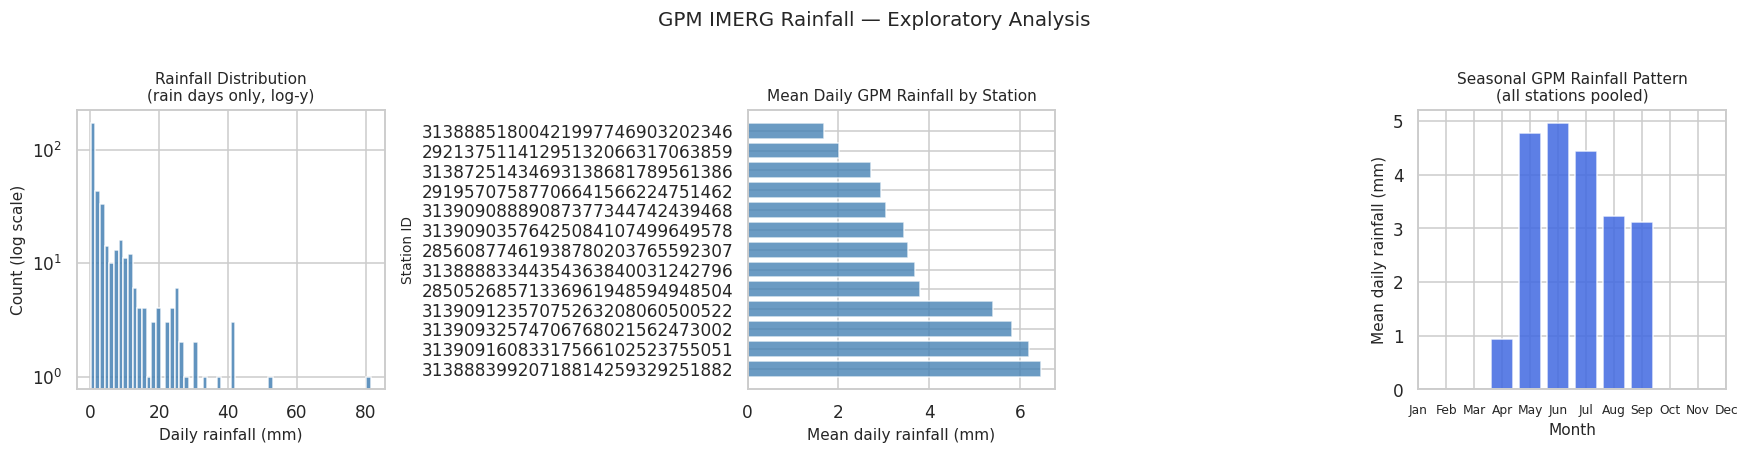

In [9]:
# ── 6b. Distribution plots ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# All days — log scale histogram
axes[0].hist(rain[rain > 0], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_yscale('log')
axes[0].set_xlabel('Daily rainfall (mm)', fontsize=10)
axes[0].set_ylabel('Count (log scale)', fontsize=10)
axes[0].set_title('Rainfall Distribution\n(rain days only, log-y)', fontsize=10)

# Box per station
rain_per_station = df.groupby('station_id')['total_accum_day'].mean().sort_values(ascending=False)
axes[1].barh(rain_per_station.index.astype(str), rain_per_station.values,
             color='steelblue', alpha=0.8)
axes[1].set_xlabel('Mean daily rainfall (mm)', fontsize=10)
axes[1].set_title('Mean Daily GPM Rainfall by Station', fontsize=10)
axes[1].set_ylabel('Station ID', fontsize=9)

# Monthly pattern (pooled all stations)
df['month'] = df['date'].dt.month
monthly = df.groupby('month')['total_accum_day'].mean()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[2].bar(monthly.index, monthly.values, color='royalblue', alpha=0.85)
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels([month_labels[m-1] for m in range(1, 13)], fontsize=8)
axes[2].set_xlabel('Month', fontsize=10)
axes[2].set_ylabel('Mean daily rainfall (mm)', fontsize=10)
axes[2].set_title('Seasonal GPM Rainfall Pattern\n(all stations pooled)', fontsize=10)

plt.suptitle('GPM IMERG Rainfall — Exploratory Analysis', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [10]:
# ── 6c. Rain event statistics ─────────────────────────────────────────────
# Define a rain event as any day with > 1 mm at a station
df['is_rain_day'] = df['total_accum_day'] > 1

rain_freq = df.groupby('station_id').agg(
    total_days   = ('date', 'count'),
    rain_days    = ('is_rain_day', 'sum'),
    mean_rain    = ('total_accum_day', 'mean'),
    p95_rain     = ('total_accum_day', lambda x: x.quantile(0.95)),
    max_rain     = ('total_accum_day', 'max'),
).reset_index()
rain_freq['rain_freq_pct'] = (rain_freq['rain_days'] / rain_freq['total_days'] * 100).round(1)

print("Rain event frequency per station:")
print(rain_freq[['station_id','total_days','rain_days','rain_freq_pct',
                  'mean_rain','p95_rain','max_rain']].to_string(index=False))


Rain event frequency per station:
                   station_id  total_days  rain_days  rain_freq_pct  mean_rain  p95_rain  max_rain
28505268571336961948594948504          40         15           37.5   3.787500    18.295      24.7
28560877461938780203765592307          37         10           27.0   3.532432    15.260      41.0
29195707587706641566224751462          38         11           28.9   2.936842    13.325      26.1
29213751141295132066317063859          56         17           30.4   2.005357    11.025      28.5
31387251434693138681789561386          41         12           29.3   2.717073     7.300      41.6
31388839920718814259329251882          43         30           69.8   6.453488    22.950      30.3
31388851800421997746903202346          93         21           22.6   1.688172     6.220      51.7
31388883344354363840031242796          45         19           42.2   3.680000    19.040      37.4
31390903576425084107499649578          34          9           26.5   3.452

## 7. Pairwise Correlation Overview

Both Pearson (linear) and Spearman (rank-based) correlations are computed. Given the skewed,  
zero-inflated nature of GPM data, **Spearman ρ is more reliable** for GPM relationships.


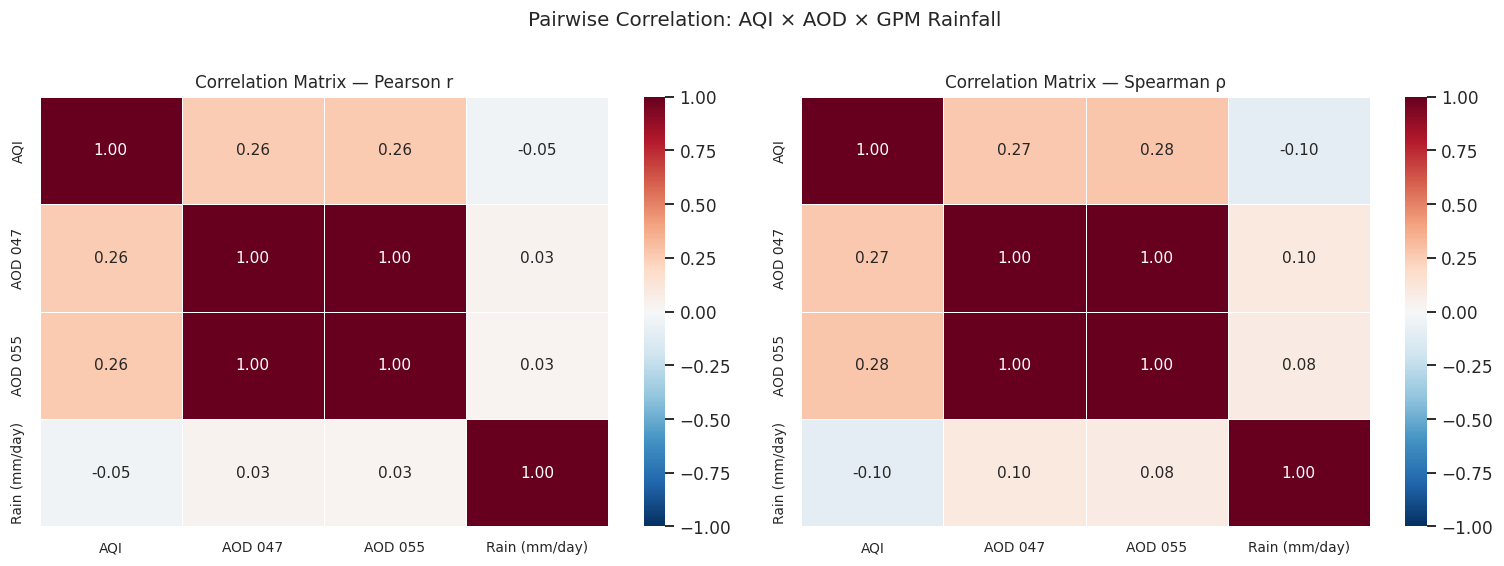

In [11]:
VARS   = ['AQI', 'Optical_Depth_047', 'Optical_Depth_055', 'total_accum_day']
LABELS = ['AQI', 'AOD 047', 'AOD 055', 'Rain (mm/day)']

corr_pearson  = df[VARS].corr(method='pearson')
corr_spearman = df[VARS].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, corr, title in zip(axes,
                            [corr_pearson, corr_spearman],
                            ['Pearson r', 'Spearman ρ']):
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
                vmin=-1, vmax=1, center=0,
                xticklabels=LABELS, yticklabels=LABELS,
                linewidths=0.5, ax=ax)
    ax.set_title(f'Correlation Matrix — {title}', fontsize=11)
    ax.tick_params(labelsize=9)

plt.suptitle('Pairwise Correlation: AQI × AOD × GPM Rainfall', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [12]:
# ── Partial correlation: GPM ↔ AQI controlling for AOD ───────────────────
# Uses the residual approach: regress each on AOD047, correlate residuals
def partial_corr(df, x, y, covariate):
    """Pearson r between residuals of x~cov and y~cov."""
    sub = df[[x, y, covariate]].dropna()
    if len(sub) < 10:
        return np.nan, np.nan
    def residuals(target, cov):
        m = LinearRegression().fit(sub[[cov]], sub[target])
        return sub[target] - m.predict(sub[[cov]])
    rx = residuals(x, covariate)
    ry = residuals(y, covariate)
    return stats.pearsonr(rx, ry)

pairs_partial = [
    ('total_accum_day', 'AQI',           'Optical_Depth_047', 'Rain ↔ AQI | AOD047'),
    ('total_accum_day', 'AQI',           'Optical_Depth_055', 'Rain ↔ AQI | AOD055'),
    ('Optical_Depth_047', 'AQI',         'total_accum_day',   'AOD047 ↔ AQI | Rain'),
    ('Optical_Depth_055', 'AQI',         'total_accum_day',   'AOD055 ↔ AQI | Rain'),
]

print("Partial Correlations (controlling for third variable):")
print(f"{'Pair':<35} {'Partial r':>10} {'p-value':>10}")
print("-" * 58)
for x, y, cov, label in pairs_partial:
    r, p = partial_corr(df, x, y, cov)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f"{label:<35} {r:>10.3f} {p:>10.4f}  {sig}")


Partial Correlations (controlling for third variable):
Pair                                 Partial r    p-value
----------------------------------------------------------
Rain ↔ AQI | AOD047                     -0.056     0.1842  ns
Rain ↔ AQI | AOD055                     -0.054     0.1960  ns
AOD047 ↔ AQI | Rain                      0.258     0.0000  ***
AOD055 ↔ AQI | Rain                      0.265     0.0000  ***


## 8. AOD vs AQI — RANSAC Analysis (Establishing the Baseline Problem)

We apply RANSAC regression to AOD vs AQI to quantify how poor the linear fit is.  
RANSAC is used because AOD-AQI scatter is known to contain many outliers from cloud contamination,  
aerosol type variability, and retrieval artifacts. A low inlier R² motivates the search for  
additional predictors such as GPM rainfall.


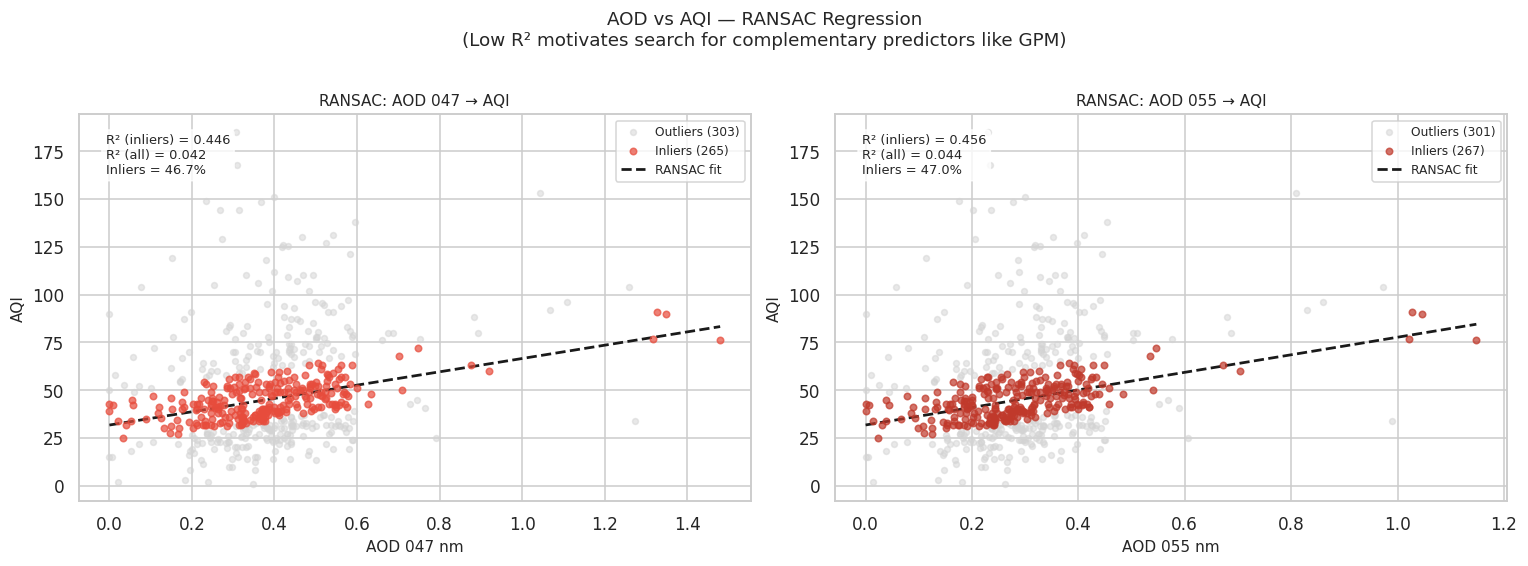

In [13]:
def ransac_plot(ax, x_vals, y_vals, xlabel, ylabel, title, color='#E74C3C'):
    """Fit RANSAC, plot inliers/outliers, annotate R² and inlier %."""
    xy = pd.DataFrame({'x': x_vals, 'y': y_vals}).dropna()
    if len(xy) < 10:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', transform=ax.transAxes)
        return

    X = xy[['x']].values
    y = xy['y'].values

    ransac = RANSACRegressor(min_samples=0.5, residual_threshold=None,
                              random_state=42)
    ransac.fit(X, y)
    mask = ransac.inlier_mask_

    x_line = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
    y_line  = ransac.predict(x_line)

    # OLS on inliers only
    r2_inliers = r2_score(y[mask], ransac.predict(X[mask]))
    r2_all     = r2_score(y, ransac.predict(X))
    pct_in     = mask.sum() / len(mask) * 100

    ax.scatter(X[~mask], y[~mask], c='lightgray', s=15, alpha=0.5,
               label=f'Outliers ({(~mask).sum()})', zorder=2)
    ax.scatter(X[mask],  y[mask],  c=color,  s=18, alpha=0.7,
               label=f'Inliers ({mask.sum()})', zorder=3)
    ax.plot(x_line, y_line, 'k--', lw=1.8, label='RANSAC fit')

    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    ax.text(0.04, 0.95,
            f'R² (inliers) = {r2_inliers:.3f}\nR² (all) = {r2_all:.3f}\nInliers = {pct_in:.1f}%',
            transform=ax.transAxes, va='top', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ransac_plot(axes[0], df['Optical_Depth_047'], df['AQI'],
            'AOD 047 nm', 'AQI', 'RANSAC: AOD 047 → AQI', color='#E74C3C')
ransac_plot(axes[1], df['Optical_Depth_055'], df['AQI'],
            'AOD 055 nm', 'AQI', 'RANSAC: AOD 055 → AQI', color='#C0392B')

plt.suptitle('AOD vs AQI — RANSAC Regression\n'
             '(Low R² motivates search for complementary predictors like GPM)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


In [14]:
# ── Store RANSAC residuals for later analysis ─────────────────────────────
sub047 = df[['Optical_Depth_047', 'AQI', 'total_accum_day']].dropna()
ransac_aod = RANSACRegressor(min_samples=0.5, random_state=42)
ransac_aod.fit(sub047[['Optical_Depth_047']], sub047['AQI'])
sub047 = sub047.copy()
sub047['ransac_pred'] = ransac_aod.predict(sub047[['Optical_Depth_047']])
sub047['residual']    = sub047['AQI'] - sub047['ransac_pred']
sub047['inlier']      = ransac_aod.inlier_mask_

print(f"RANSAC AOD047 → AQI:")
print(f"  Inliers  : {sub047['inlier'].sum()} / {len(sub047)}")
print(f"  R² (all) : {r2_score(sub047['AQI'], sub047['ransac_pred']):.4f}")
print(f"  MAE      : {mean_absolute_error(sub047['AQI'], sub047['ransac_pred']):.2f}")


RANSAC AOD047 → AQI:
  Inliers  : 265 / 568
  R² (all) : 0.0418
  MAE      : 18.27


## 9. GPM Rainfall vs AQI and AOD — RANSAC Analysis

We now apply the same RANSAC framework to GPM-based relationships.  
This lets us directly compare the predictive signal strength of GPM against AOD.


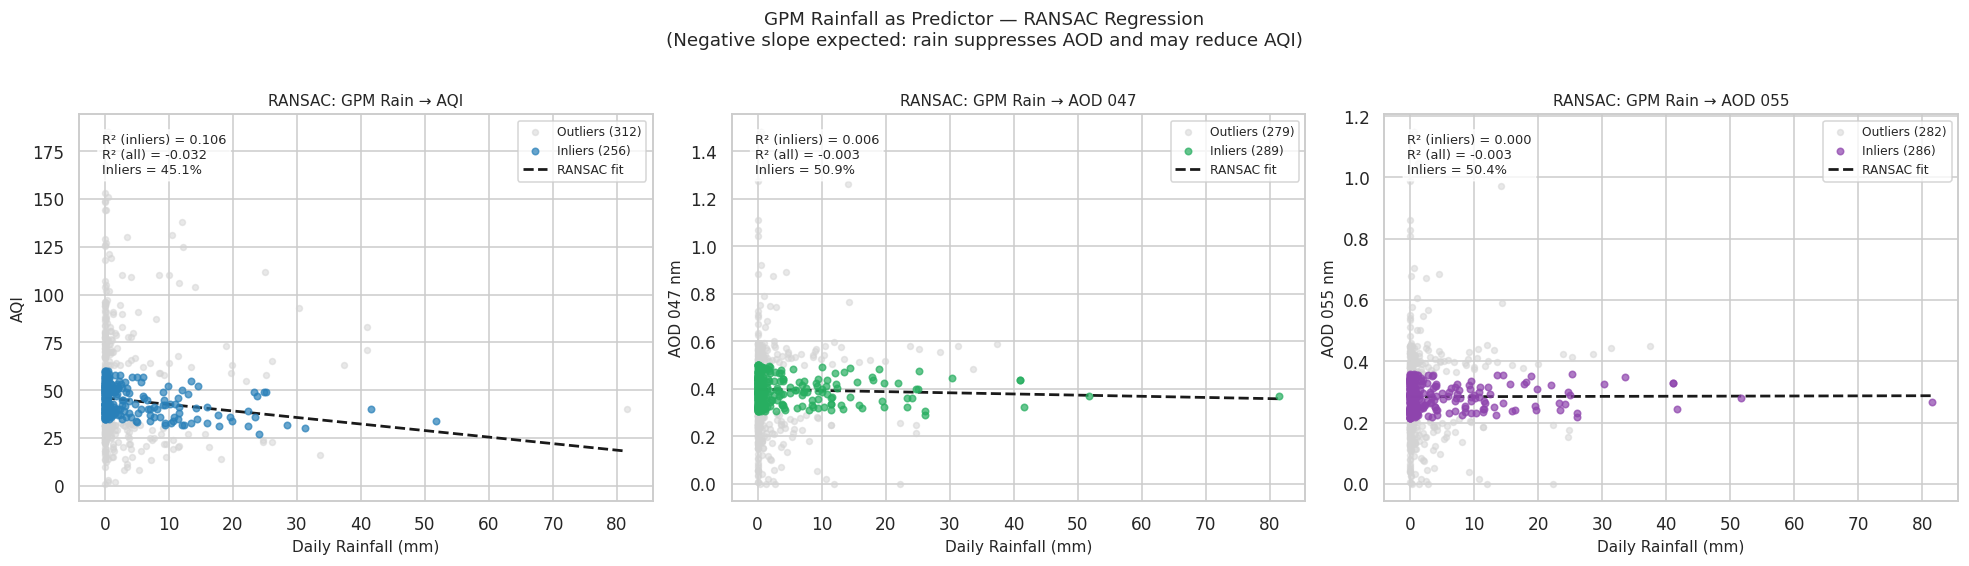

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ransac_plot(axes[0], df['total_accum_day'], df['AQI'],
            'Daily Rainfall (mm)', 'AQI',
            'RANSAC: GPM Rain → AQI', color='#2980B9')

ransac_plot(axes[1], df['total_accum_day'], df['Optical_Depth_047'],
            'Daily Rainfall (mm)', 'AOD 047 nm',
            'RANSAC: GPM Rain → AOD 047', color='#27AE60')

ransac_plot(axes[2], df['total_accum_day'], df['Optical_Depth_055'],
            'Daily Rainfall (mm)', 'AOD 055 nm',
            'RANSAC: GPM Rain → AOD 055', color='#8E44AD')

plt.suptitle('GPM Rainfall as Predictor — RANSAC Regression\n'
             '(Negative slope expected: rain suppresses AOD and may reduce AQI)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


In [16]:
# ── RANSAC R² comparison table: AOD alone vs GPM alone ───────────────────
from sklearn.linear_model import RANSACRegressor
from sklearn.metrics import r2_score

def fit_ransac_r2(x_col, y_col):
    sub = df[[x_col, y_col]].dropna()
    if len(sub) < 20:
        return np.nan, np.nan
    rsc = RANSACRegressor(min_samples=0.5, random_state=42)
    rsc.fit(sub[[x_col]], sub[y_col])
    r2_all = r2_score(sub[y_col], rsc.predict(sub[[x_col]]))
    r2_in  = r2_score(sub[y_col][rsc.inlier_mask_],
                      rsc.predict(sub[[x_col]])[rsc.inlier_mask_])
    return round(r2_all, 4), round(r2_in, 4)

comparisons = [
    ('Optical_Depth_047', 'AQI', 'AOD047 → AQI'),
    ('Optical_Depth_055', 'AQI', 'AOD055 → AQI'),
    ('total_accum_day',   'AQI', 'GPM Rain → AQI'),
    ('total_accum_day',   'Optical_Depth_047', 'GPM Rain → AOD047'),
    ('total_accum_day',   'Optical_Depth_055', 'GPM Rain → AOD055'),
]

print(f"{'Pair':<35} {'R² (all)':>10} {'R² (inliers)':>14}")
print("-" * 62)
for x_col, y_col, label in comparisons:
    r2_all, r2_in = fit_ransac_r2(x_col, y_col)
    print(f"{label:<35} {r2_all:>10.4f} {r2_in:>14.4f}")


Pair                                  R² (all)   R² (inliers)
--------------------------------------------------------------
AOD047 → AQI                            0.0418         0.4463
AOD055 → AQI                            0.0441         0.4556
GPM Rain → AQI                         -0.0317         0.1064
GPM Rain → AOD047                      -0.0027         0.0061
GPM Rain → AOD055                      -0.0032         0.0001


## 10. RANSAC Residual Analysis — Does GPM Explain AOD's Prediction Errors?

If GPM carries information orthogonal to AOD, then the **residuals** from the AOD→AQI RANSAC fit  
should correlate with GPM rainfall. A significant correlation here means GPM captures variance  
that AOD misses — the key evidence for using GPM as a complementary predictor.


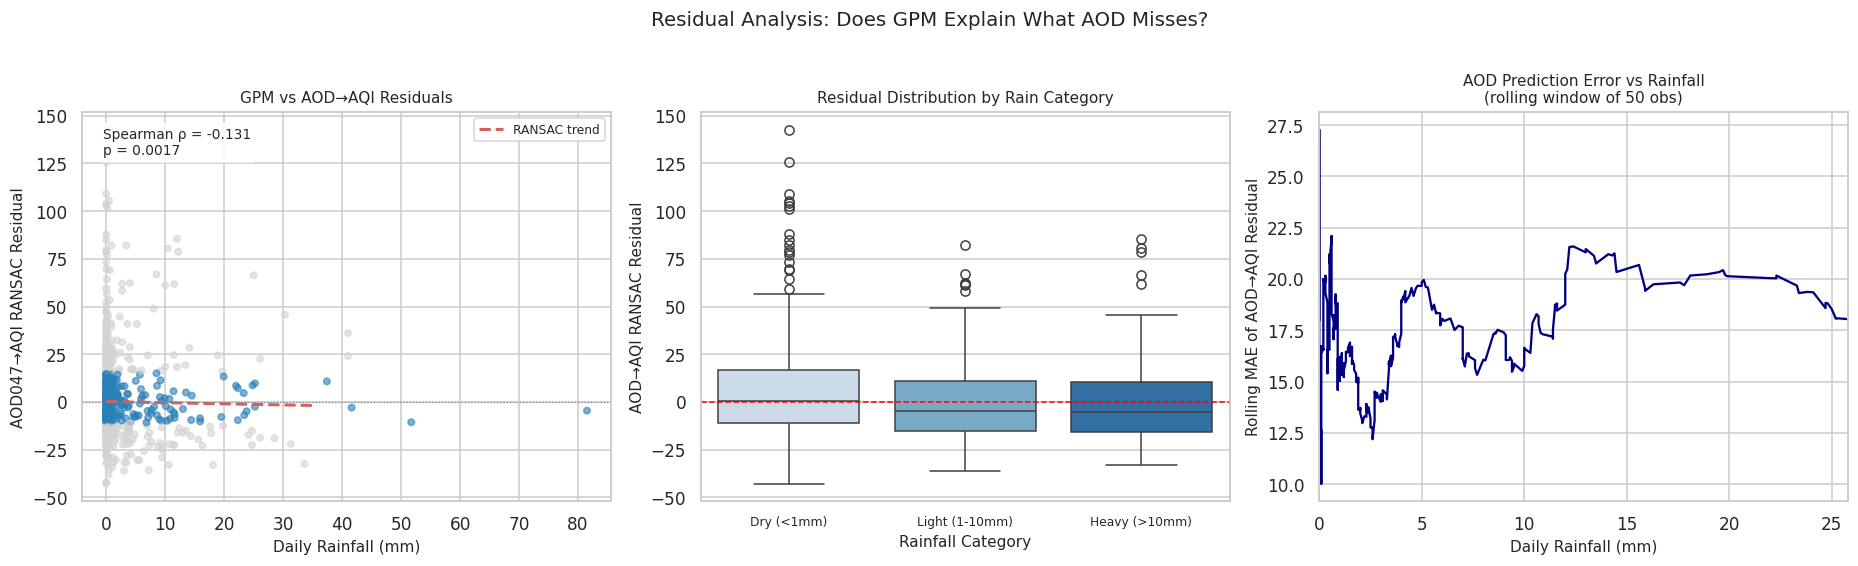


Key insight: If residuals are systematically lower (or higher) on rainy days,
GPM contains information orthogonal to AOD that improves AQI prediction.


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── Panel 1: Residual vs GPM (all points) ────────────────────────────────
ax = axes[0]
ax.scatter(sub047['total_accum_day'], sub047['residual'],
           c=sub047['inlier'].map({True: '#2980B9', False: 'lightgray'}),
           s=18, alpha=0.6)
# RANSAC on residual vs GPM
res_sub = sub047[['total_accum_day', 'residual']].dropna()
rsc_res = RANSACRegressor(min_samples=0.5, random_state=42)
rsc_res.fit(res_sub[['total_accum_day']], res_sub['residual'])
x_line = np.linspace(0, res_sub['total_accum_day'].quantile(0.99), 100).reshape(-1, 1)
ax.plot(x_line, rsc_res.predict(x_line), 'r--', lw=2, label='RANSAC trend')
r_sp, p_sp = stats.spearmanr(sub047['total_accum_day'], sub047['residual'])
ax.axhline(0, color='gray', lw=0.8, ls=':')
ax.set_xlabel('Daily Rainfall (mm)', fontsize=10)
ax.set_ylabel('AOD047→AQI RANSAC Residual', fontsize=10)
ax.set_title('GPM vs AOD→AQI Residuals', fontsize=10)
ax.text(0.04, 0.96, f'Spearman ρ = {r_sp:.3f}\np = {p_sp:.4f}',
        transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))
ax.legend(fontsize=8)

# ── Panel 2: Residual distribution by rain bin ───────────────────────────
ax = axes[1]
bins_rain   = [-np.inf, 1, 10, np.inf]
bin_labels  = ['Dry (<1mm)', 'Light (1-10mm)', 'Heavy (>10mm)']
sub047['rain_bin'] = pd.cut(sub047['total_accum_day'], bins=bins_rain, labels=bin_labels)
sns.boxplot(data=sub047, x='rain_bin', y='residual', order=bin_labels,
            palette='Blues', ax=ax)
ax.axhline(0, color='red', lw=1, ls='--')
ax.set_xlabel('Rainfall Category', fontsize=10)
ax.set_ylabel('AOD→AQI RANSAC Residual', fontsize=10)
ax.set_title('Residual Distribution by Rain Category', fontsize=10)
ax.tick_params(axis='x', labelsize=8)

# ── Panel 3: Cumulative explained variance ───────────────────────────────
ax = axes[2]
# Absolute residual as proxy for unexplained error
sub047['abs_residual'] = sub047['residual'].abs()
# Sort by rain and compute rolling mean absolute residual
sorted_sub = sub047.sort_values('total_accum_day')
rain_vals = sorted_sub['total_accum_day'].values
abs_res   = sorted_sub['abs_residual'].rolling(50, min_periods=5).mean().values
ax.plot(rain_vals, abs_res, color='navy', lw=1.5)
ax.set_xlabel('Daily Rainfall (mm)', fontsize=10)
ax.set_ylabel('Rolling MAE of AOD→AQI Residual', fontsize=10)
ax.set_title('AOD Prediction Error vs Rainfall\n(rolling window of 50 obs)', fontsize=10)
ax.set_xlim(0, np.percentile(rain_vals, 98))

plt.suptitle('Residual Analysis: Does GPM Explain What AOD Misses?', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\nKey insight: If residuals are systematically lower (or higher) on rainy days,")
print("GPM contains information orthogonal to AOD that improves AQI prediction.")


## 11. Full Scatter Matrix — AQI × AOD × GPM

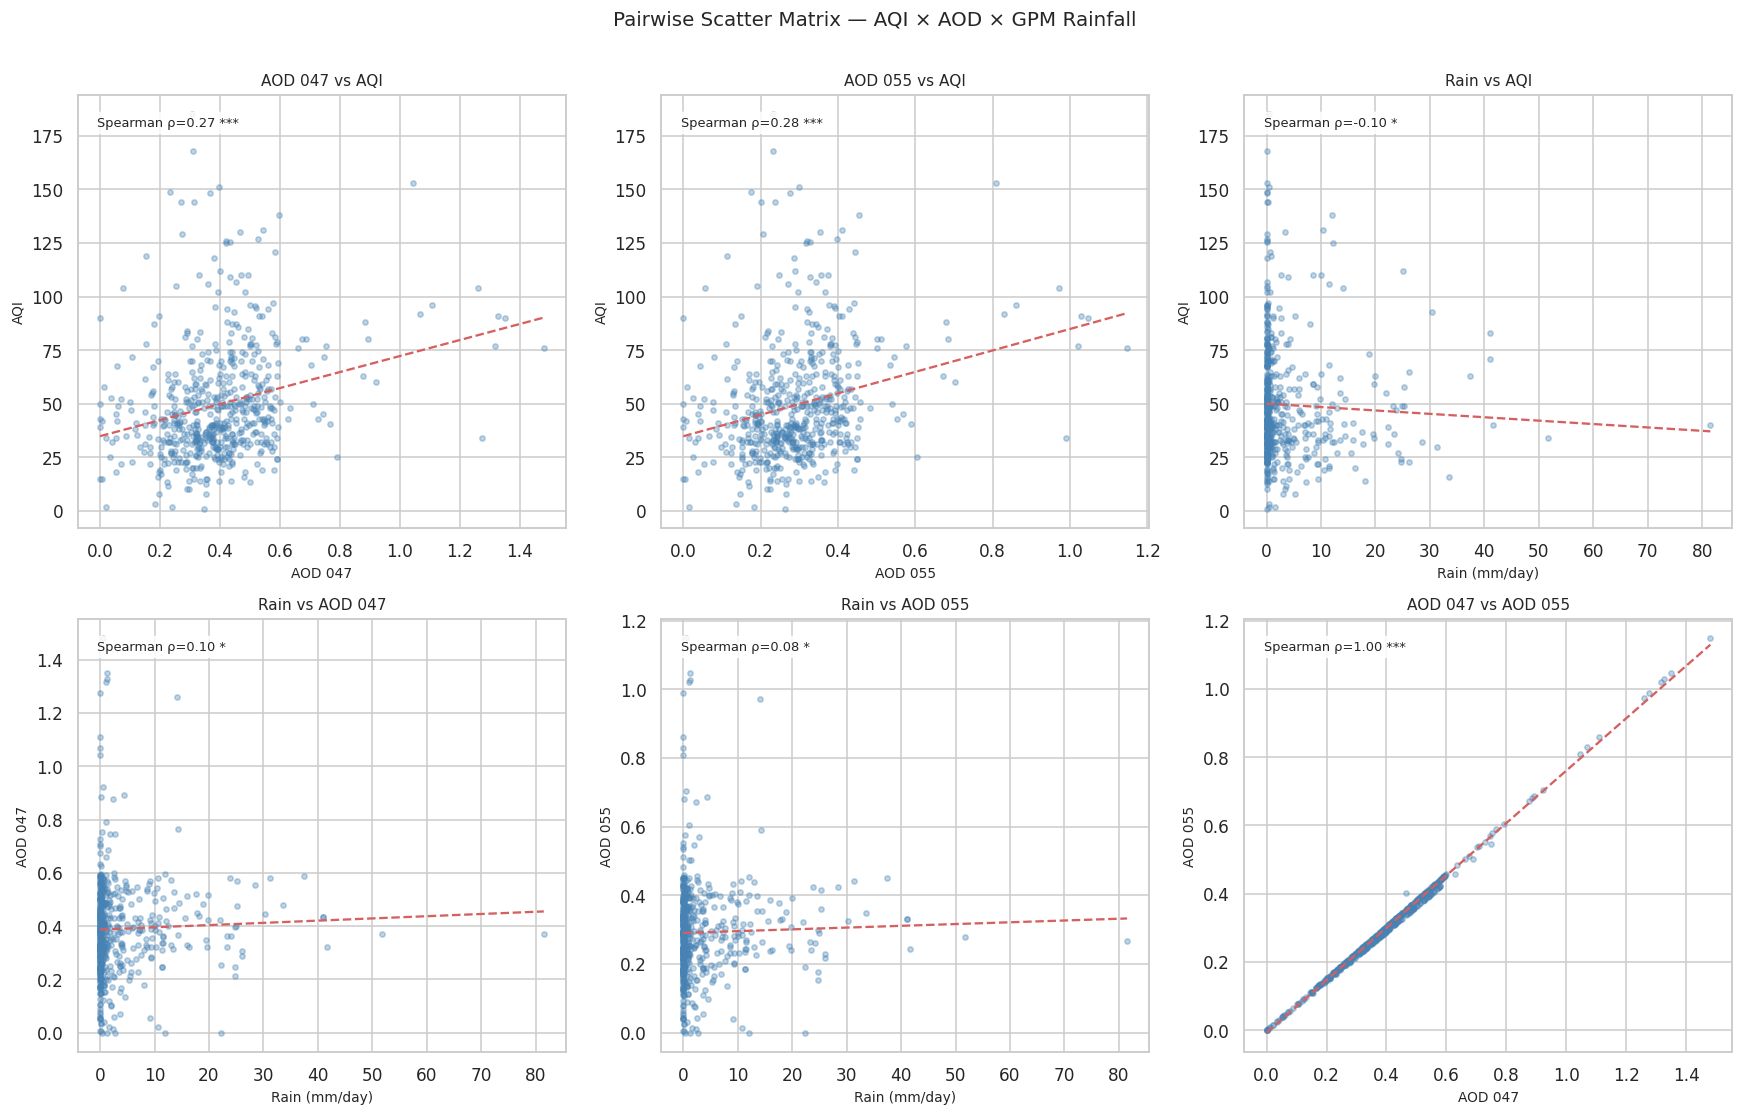

In [18]:
df_plot = df[VARS].dropna()

pairs = [
    ('Optical_Depth_047', 'AQI',               'AOD 047 vs AQI'),
    ('Optical_Depth_055', 'AQI',               'AOD 055 vs AQI'),
    ('total_accum_day',   'AQI',               'Rain vs AQI'),
    ('total_accum_day',   'Optical_Depth_047', 'Rain vs AOD 047'),
    ('total_accum_day',   'Optical_Depth_055', 'Rain vs AOD 055'),
    ('Optical_Depth_047', 'Optical_Depth_055', 'AOD 047 vs AOD 055'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, (x, y, title) in zip(axes.flat, pairs):
    sub = df_plot[[x, y]].dropna()
    r_sp, p_sp = stats.spearmanr(sub[x], sub[y])
    
    ax.scatter(sub[x], sub[y], s=12, alpha=0.35, color='steelblue', zorder=2)
    
    # OLS trend line
    m, b = np.polyfit(sub[x], sub[y], 1)
    x_line = np.linspace(sub[x].min(), sub[x].max(), 100)
    ax.plot(x_line, m * x_line + b, 'r--', lw=1.5, label='OLS')
    
    ax.set_xlabel(x.replace('Optical_Depth_', 'AOD ').replace('total_accum_day', 'Rain (mm/day)'),
                  fontsize=9)
    ax.set_ylabel(y.replace('Optical_Depth_', 'AOD ').replace('total_accum_day', 'Rain (mm/day)'),
                  fontsize=9)
    ax.set_title(title, fontsize=10)
    sig = '***' if p_sp < 0.001 else ('**' if p_sp < 0.01 else ('*' if p_sp < 0.05 else 'ns'))
    ax.text(0.04, 0.95, f'Spearman ρ={r_sp:.2f} {sig}',
            transform=ax.transAxes, va='top', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))

plt.suptitle('Pairwise Scatter Matrix — AQI × AOD × GPM Rainfall', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 12. Rain Washout Effect — AQI and AOD by Rainfall Category

If GPM is a useful predictor, we expect systematically lower AQI and AOD on rainy days  
(wet scavenging of aerosols). We test this with boxplots and non-parametric statistics.


Records per rainfall bin:
rain_bin
Dry (<1 mm)        350
Light (1–10 mm)    151
Heavy (>10 mm)      67
Name: count, dtype: int64


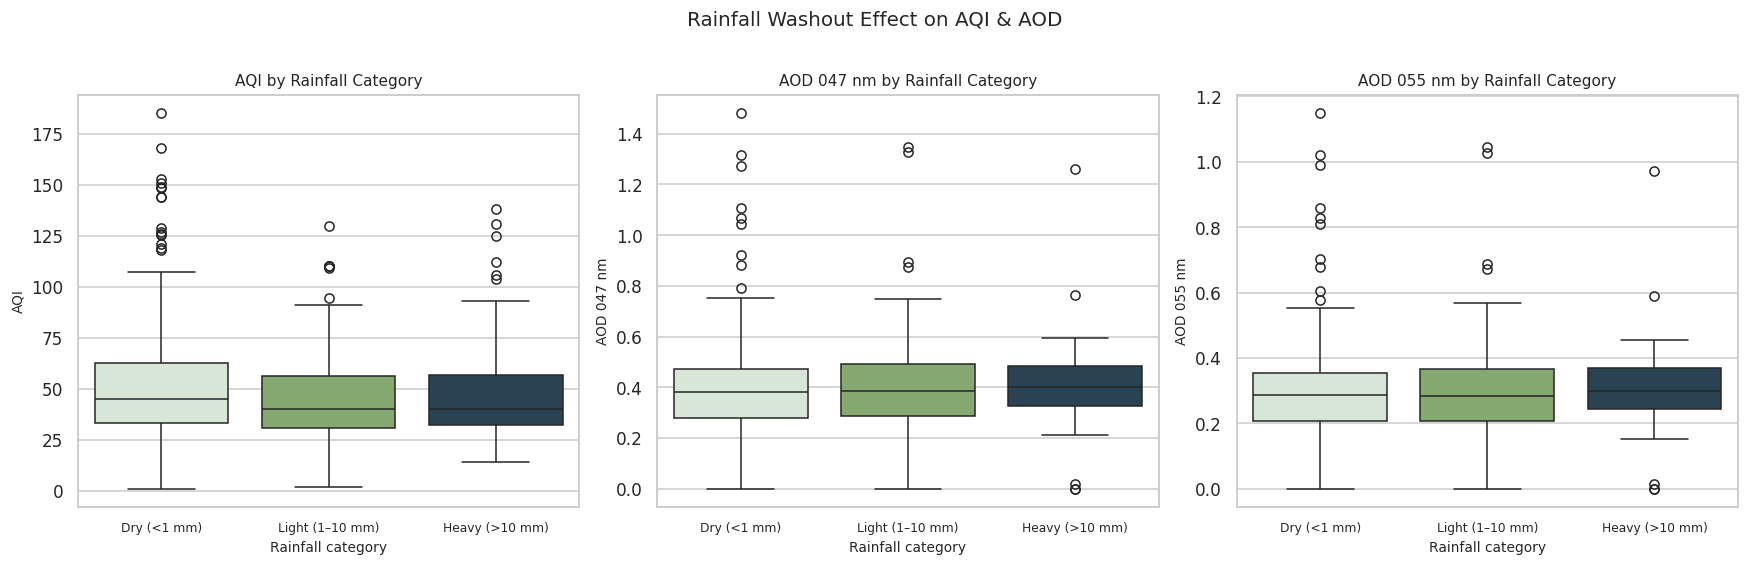

In [19]:
bins   = [-np.inf, 1, 10, np.inf]
labels = ['Dry (<1 mm)', 'Light (1–10 mm)', 'Heavy (>10 mm)']
df['rain_bin'] = pd.cut(df['total_accum_day'], bins=bins, labels=labels)

print("Records per rainfall bin:")
print(df['rain_bin'].value_counts().sort_index())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, label in zip(axes,
                           ['AQI', 'Optical_Depth_047', 'Optical_Depth_055'],
                           ['AQI', 'AOD 047 nm', 'AOD 055 nm']):
    sub = df[['rain_bin', col]].dropna()
    sns.boxplot(data=sub, x='rain_bin', y=col, order=labels,
                palette=['#D5E8D4', '#82B366', '#23445A'], ax=ax)
    ax.set_xlabel('Rainfall category', fontsize=9)
    ax.set_ylabel(label, fontsize=9)
    ax.set_title(f'{label} by Rainfall Category', fontsize=10)
    ax.tick_params(axis='x', labelsize=8)

plt.suptitle('Rainfall Washout Effect on AQI & AOD', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [20]:
# ── Kruskal-Wallis + pairwise Mann-Whitney U tests ───────────────────────
print("Statistical Tests Across Rainfall Bins\n")
print(f"{'Variable':<20} {'Kruskal-Wallis':^25} {'Dry vs Light':^20} {'Dry vs Heavy':^20}")
print("-" * 88)

for col, label in zip(['AQI', 'Optical_Depth_047', 'Optical_Depth_055'],
                      ['AQI', 'AOD 047', 'AOD 055']):
    groups = {b: df.loc[df['rain_bin'] == b, col].dropna().values for b in labels}
    groups = {k: v for k, v in groups.items() if len(v) >= 3}

    if len(groups) >= 2:
        h, p_kw = stats.kruskal(*groups.values())
        sig_kw = '***' if p_kw < 0.001 else ('**' if p_kw < 0.01 else ('*' if p_kw < 0.05 else 'ns'))

        def mw(a_key, b_key):
            if a_key in groups and b_key in groups:
                _, p = mannwhitneyu(groups[a_key], groups[b_key], alternative='two-sided')
                return '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
            return 'n/a'

        dl = mw('Dry (<1 mm)', 'Light (1–10 mm)')
        dh = mw('Dry (<1 mm)', 'Heavy (>10 mm)')
        print(f"{label:<20} H={h:>6.2f} p={p_kw:<8.4f}{sig_kw:<4} {dl:^20} {dh:^20}")


Statistical Tests Across Rainfall Bins

Variable                  Kruskal-Wallis           Dry vs Light         Dry vs Heavy    
----------------------------------------------------------------------------------------
AQI                  H=  6.80 p=0.0334  *             *                    ns         
AOD 047              H=  3.29 p=0.1927  ns            ns                   ns         
AOD 055              H=  2.62 p=0.2702  ns            ns                   ns         


## 13. Temporal Lag Analysis — GPM Lead Time on AOD / AQI

Rainfall may suppress aerosols not on the same day but 1–3 days later as particles are  
scavenged and boundary layer dynamics recover. We shift GPM by 0–5 days and compute  
Spearman ρ with same-day AQI and AOD to identify the **optimal washout lag**.


In [21]:
MAX_LAG = 5   # days

lag_results = []
for lag in range(MAX_LAG + 1):
    tmp = df[['station_id', 'date', 'AQI', 'Optical_Depth_047',
              'Optical_Depth_055', 'total_accum_day']].copy()
    tmp['date_shifted'] = tmp['date'] + pd.Timedelta(days=lag)

    merged_lag = df[['station_id', 'date', 'AQI',
                     'Optical_Depth_047', 'Optical_Depth_055']].merge(
        tmp[['station_id', 'date_shifted', 'total_accum_day']].rename(
            columns={'date_shifted': 'date'}),
        on=['station_id', 'date'], how='inner'
    ).dropna()

    for target, tlabel in [('AQI', 'AQI'),
                            ('Optical_Depth_047', 'AOD 047'),
                            ('Optical_Depth_055', 'AOD 055')]:
        if len(merged_lag) < 5:
            continue
        r, p = stats.spearmanr(merged_lag['total_accum_day'], merged_lag[target])
        lag_results.append({'lag_days': lag, 'target': tlabel,
                            'spearman_r': round(r, 4), 'p_value': round(p, 4),
                            'n': len(merged_lag)})

df_lag = pd.DataFrame(lag_results)

# Also compute LEAD (negative lag: today's AQI predicted by future rain — should be noise)
lead_results = []
for lead in range(1, 4):
    tmp = df[['station_id', 'date', 'total_accum_day']].copy()
    tmp['date_lead'] = tmp['date'] - pd.Timedelta(days=lead)
    merged_lead = df[['station_id', 'date', 'AQI', 'Optical_Depth_047']].merge(
        tmp[['station_id', 'date_lead', 'total_accum_day']].rename(
            columns={'date_lead': 'date'}),
        on=['station_id', 'date'], how='inner'
    ).dropna()
    for target, tlabel in [('AQI', 'AQI'), ('Optical_Depth_047', 'AOD 047')]:
        r, p = stats.spearmanr(merged_lead['total_accum_day'], merged_lead[target])
        lead_results.append({'lag_days': -lead, 'target': tlabel,
                             'spearman_r': round(r, 4), 'p_value': round(p, 4)})

df_lead = pd.DataFrame(lead_results)
df_lag_full = pd.concat([df_lead, df_lag], ignore_index=True).sort_values(['target', 'lag_days'])
print(df_lag_full[['lag_days','target','spearman_r','p_value']].to_string(index=False))


 lag_days  target  spearman_r  p_value
       -3 AOD 047     -0.0212   0.7682
       -2 AOD 047      0.1141   0.1068
       -1 AOD 047      0.0679   0.2998
        0 AOD 047      0.0965   0.0214
        1 AOD 047      0.0314   0.6320
        2 AOD 047     -0.1058   0.1350
        3 AOD 047     -0.0372   0.6054
        4 AOD 047      0.0911   0.2266
        5 AOD 047     -0.0645   0.3874
        0 AOD 055      0.0831   0.0477
        1 AOD 055      0.0214   0.7443
        2 AOD 055     -0.1193   0.0917
        3 AOD 055     -0.0472   0.5123
        4 AOD 055      0.0848   0.2604
        5 AOD 055     -0.0759   0.3087
       -3     AQI     -0.0139   0.8470
       -2     AQI      0.0469   0.5083
       -1     AQI      0.0774   0.2372
        0     AQI     -0.1037   0.0134
        1     AQI     -0.1194   0.0677
        2     AQI     -0.0874   0.2172
        3     AQI     -0.1735   0.0153
        4     AQI      0.1476   0.0492
        5     AQI     -0.0204   0.7848


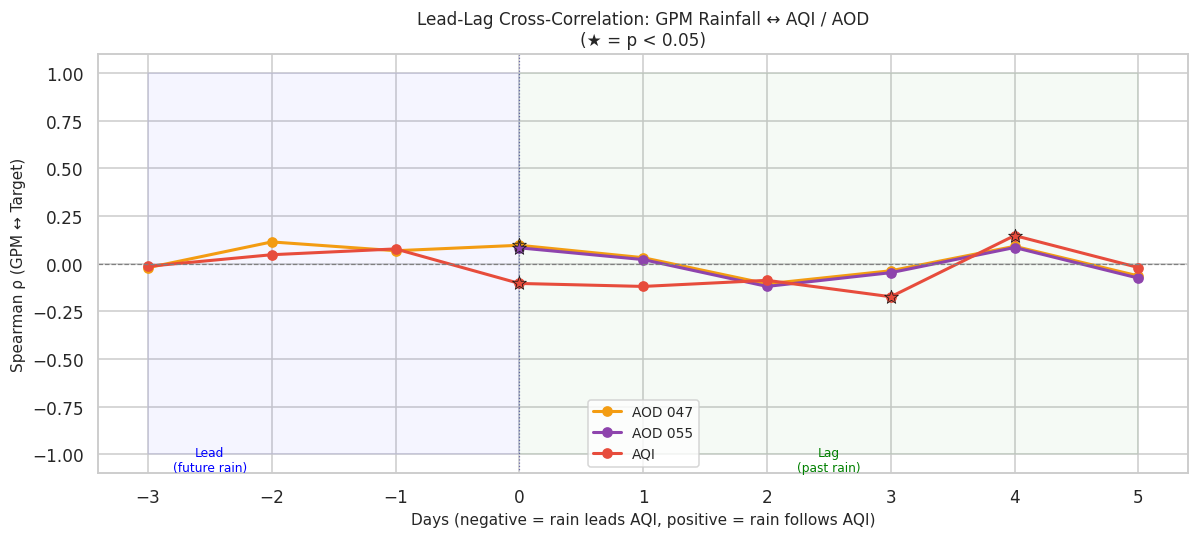

In [22]:
fig, ax = plt.subplots(figsize=(11, 5))
palette = {'AQI': '#E74C3C', 'AOD 047': '#F39C12', 'AOD 055': '#8E44AD'}

for target, group in df_lag_full.groupby('target'):
    group = group.sort_values('lag_days')
    sig_mask = group['p_value'] < 0.05
    ax.plot(group['lag_days'], group['spearman_r'],
            marker='o', color=palette.get(target, 'gray'),
            label=target, lw=2)
    # Mark significant points
    ax.scatter(group.loc[sig_mask, 'lag_days'],
               group.loc[sig_mask, 'spearman_r'],
               color=palette.get(target, 'gray'), s=90, zorder=5,
               marker='*', edgecolors='k', lw=0.5)

ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.axvline(0, color='navy', lw=0.8, ls=':', alpha=0.5)
ax.fill_betweenx([-1, 1], -3, 0, alpha=0.04, color='blue')
ax.fill_betweenx([-1, 1], 0, 5,  alpha=0.04, color='green')
ax.text(-2.5, ax.get_ylim()[0] + 0.01, 'Lead\n(future rain)', ha='center', fontsize=8, color='blue')
ax.text(2.5,  ax.get_ylim()[0] + 0.01, 'Lag\n(past rain)',   ha='center', fontsize=8, color='green')

ax.set_xlabel('Days (negative = rain leads AQI, positive = rain follows AQI)', fontsize=10)
ax.set_ylabel('Spearman ρ (GPM ↔ Target)', fontsize=10)
ax.set_title('Lead-Lag Cross-Correlation: GPM Rainfall ↔ AQI / AOD\n'
             '(★ = p < 0.05)', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 14. Per-Station Correlation Summary

In [23]:
station_rows = []
for sid, grp in df.groupby('station_id'):
    sub = grp.dropna(subset=['AQI', 'Optical_Depth_047',
                              'Optical_Depth_055', 'total_accum_day'])
    if len(sub) < MIN_OBS:
        continue
    row = {'station_id': sid, 'n': len(sub)}
    for x, y, key in [
        ('Optical_Depth_047', 'AQI',           'r_AOD047_AQI'),
        ('Optical_Depth_055', 'AQI',           'r_AOD055_AQI'),
        ('total_accum_day',   'AQI',           'r_rain_AQI'),
        ('total_accum_day',   'Optical_Depth_047', 'r_rain_AOD047'),
        ('total_accum_day',   'Optical_Depth_055', 'r_rain_AOD055'),
    ]:
        pair = sub[[x, y]].dropna()
        if len(pair) >= MIN_OBS:
            r, p = stats.spearmanr(pair[x], pair[y])
        else:
            r, p = np.nan, np.nan
        row[key] = round(r, 3)
        row[key + '_p'] = round(p, 4) if not np.isnan(p) else np.nan
    station_rows.append(row)

df_station_corr = pd.DataFrame(station_rows)
print(f"Per-station correlation table ({len(df_station_corr)} stations):")
df_station_corr


Per-station correlation table (13 stations):


,station_id,n,r_AOD047_AQI,r_AOD047_AQI_p,r_AOD055_AQI,r_AOD055_AQI_p,r_rain_AQI,r_rain_AQI_p,r_rain_AOD047,r_rain_AOD047_p,r_rain_AOD055,r_rain_AOD055_p
0,28505268571336961948594948504,40,0.605,0.0000,0.605,0.0000,-0.161,0.3209,0.195,0.2281,0.196,0.2254
1,28560877461938780203765592307,37,0.344,0.0368,0.342,0.0382,-0.245,0.1439,0.039,0.8207,0.042,0.8067
2,29195707587706641566224751462,38,0.307,0.0610,0.309,0.0591,-0.068,0.6842,-0.060,0.7185,-0.060,0.7185
3,29213751141295132066317063859,56,0.241,0.0732,0.241,0.0735,0.085,0.5337,-0.051,0.7101,-0.044,0.7456
4,31387251434693138681789561386,41,0.282,0.0741,0.282,0.0741,-0.223,0.1605,0.068,0.6740,0.068,0.6740
5,31388839920718814259329251882,43,0.135,0.3885,0.135,0.3885,0.269,0.0807,-0.027,0.8637,-0.027,0.8637
6,31388851800421997746903202346,93,0.237,0.0220,0.238,0.0214,-0.199,0.0558,0.180,0.0838,0.184,0.0779
7,31388883344354363840031242796,45,0.222,0.1420,0.222,0.1420,-0.009,0.9522,0.253,0.0939,0.253,0.0939
8,31390903576425084107499649578,34,0.037,0.8368,0.037,0.8375,-0.264,0.1309,0.137,0.4400,0.139,0.4345
9,31390908889087377344742439468,34,0.278,0.1119,0.282,0.1063,0.033,0.8533,0.260,0.1378,0.259,0.1387


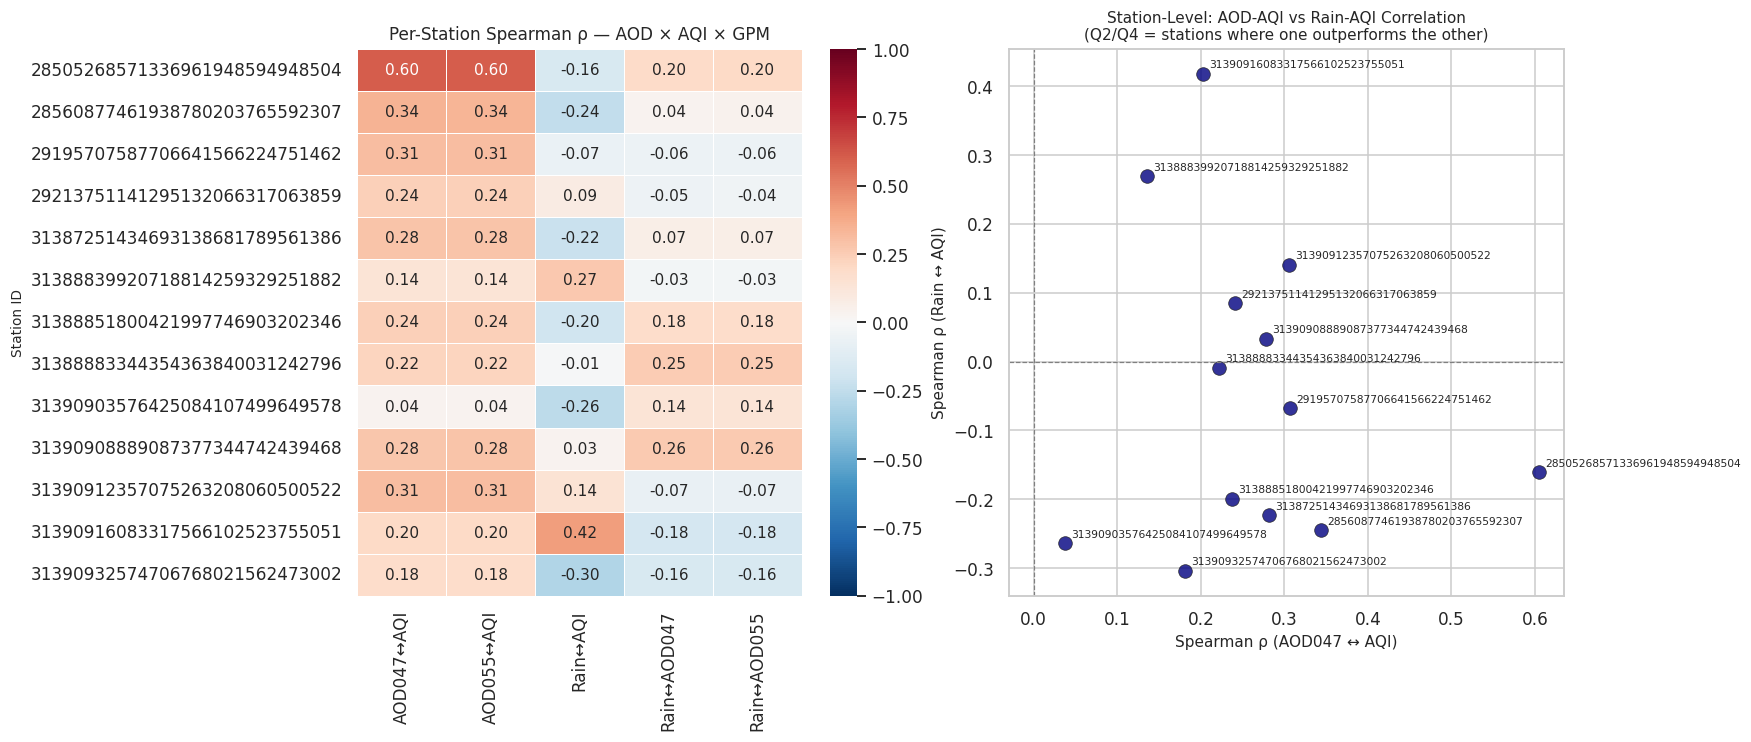

In [24]:
r_cols   = ['r_AOD047_AQI', 'r_AOD055_AQI', 'r_rain_AQI', 'r_rain_AOD047', 'r_rain_AOD055']
r_labels = ['AOD047↔AQI', 'AOD055↔AQI', 'Rain↔AQI', 'Rain↔AOD047', 'Rain↔AOD055']

heat = df_station_corr.set_index('station_id')[r_cols]

fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(heat) * 0.45 + 1)))

# Heatmap
sns.heatmap(heat, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, center=0,
            xticklabels=r_labels, linewidths=0.4, ax=axes[0])
axes[0].set_xlabel('')
axes[0].set_ylabel('Station ID', fontsize=9)
axes[0].set_title('Per-Station Spearman ρ — AOD × AQI × GPM', fontsize=11)

# Summary: rain-AQI vs AOD-AQI per station
axes[1].scatter(df_station_corr['r_AOD047_AQI'], df_station_corr['r_rain_AQI'],
                s=80, color='navy', alpha=0.8, edgecolors='k', lw=0.5)
for _, row in df_station_corr.iterrows():
    axes[1].annotate(str(row['station_id']),
                     (row['r_AOD047_AQI'], row['r_rain_AQI']),
                     fontsize=7, ha='left', xytext=(4, 4), textcoords='offset points')
axes[1].axhline(0, color='gray', lw=0.8, ls='--')
axes[1].axvline(0, color='gray', lw=0.8, ls='--')
axes[1].set_xlabel('Spearman ρ (AOD047 ↔ AQI)', fontsize=10)
axes[1].set_ylabel('Spearman ρ (Rain ↔ AQI)', fontsize=10)
axes[1].set_title('Station-Level: AOD-AQI vs Rain-AQI Correlation\n'
                  '(Q2/Q4 = stations where one outperforms the other)', fontsize=10)

plt.tight_layout()
plt.show()


## 15. Multivariate AQI Prediction: AOD + GPM — Linear & Random Forest

We compare AQI predictive performance across feature sets using 5-fold cross-validated R².  
The key question: **does adding GPM to AOD significantly improve R²?**  
We test with both linear regression and a non-linear Random Forest (which captures thresholds  
and interactions, e.g., heavy rain above a threshold suppresses AQI more than linearly).


In [25]:
complete = df[['AQI', 'Optical_Depth_047', 'Optical_Depth_055',
               'total_accum_day']].dropna()
y = complete['AQI'].values

feature_sets = {
    'AOD047 only':            ['Optical_Depth_047'],
    'AOD055 only':            ['Optical_Depth_055'],
    'Rain only':              ['total_accum_day'],
    'AOD047 + AOD055':        ['Optical_Depth_047', 'Optical_Depth_055'],
    'AOD047 + Rain':          ['Optical_Depth_047', 'total_accum_day'],
    'AOD055 + Rain':          ['Optical_Depth_055', 'total_accum_day'],
    'AOD047 + AOD055 + Rain': ['Optical_Depth_047', 'Optical_Depth_055', 'total_accum_day'],
}

cv_rows = []
for name, feats in feature_sets.items():
    X = complete[feats].values
    for model_name, model in [
        ('Linear', make_pipeline(StandardScaler(), LinearRegression())),
        ('RandomForest', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ]:
        scores = cross_val_score(model, X, y, cv=5, scoring='r2')
        cv_rows.append({
            'Feature set': name,
            'Model': model_name,
            'Mean R²': round(scores.mean(), 4),
            'Std R²':  round(scores.std(),  4),
        })

df_cv = pd.DataFrame(cv_rows)
pivot = df_cv.pivot(index='Feature set', columns='Model', values='Mean R²')
pivot_std = df_cv.pivot(index='Feature set', columns='Model', values='Std R²')

order = df_cv.groupby('Feature set')['Mean R²'].max().sort_values(ascending=False).index
pivot = pivot.loc[order]
pivot_std = pivot_std.loc[order]

print(df_cv.to_string(index=False))


           Feature set        Model  Mean R²  Std R²
           AOD047 only       Linear  -0.0922  0.1753
           AOD047 only RandomForest  -0.6545  0.4151
           AOD055 only       Linear  -0.0806  0.1585
           AOD055 only RandomForest  -0.6312  0.4410
             Rain only       Linear  -0.1636  0.1102
             Rain only RandomForest  -0.4776  0.3864
       AOD047 + AOD055       Linear  -0.0873  0.1632
       AOD047 + AOD055 RandomForest  -0.5734  0.2576
         AOD047 + Rain       Linear  -0.0914  0.1672
         AOD047 + Rain RandomForest  -0.5573  0.3107
         AOD055 + Rain       Linear  -0.0804  0.1507
         AOD055 + Rain RandomForest  -0.5760  0.3310
AOD047 + AOD055 + Rain       Linear  -0.0940  0.1594
AOD047 + AOD055 + Rain RandomForest  -0.5094  0.2611


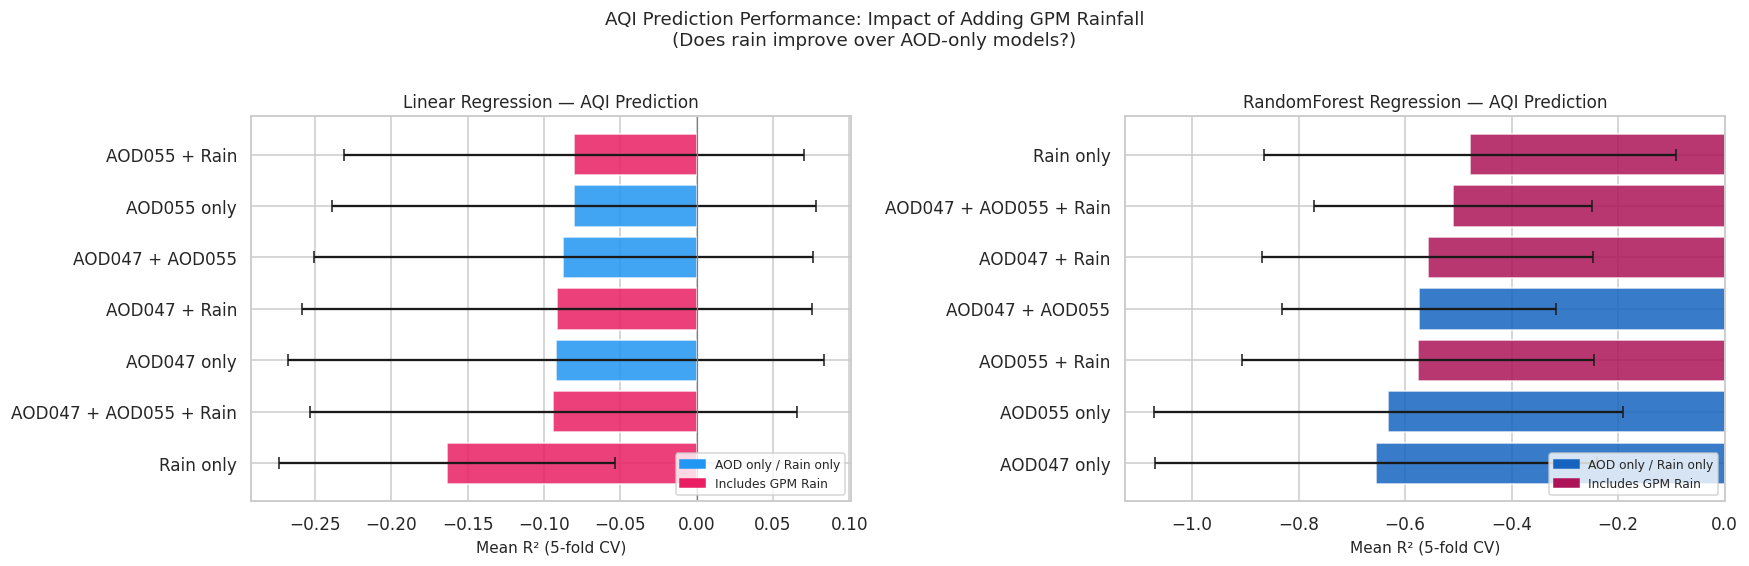

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, model_name, color_no_rain, color_rain in [
    (axes[0], 'Linear',       '#2196F3', '#E91E63'),
    (axes[1], 'RandomForest', '#1565C0', '#AD1457'),
]:
    sub = df_cv[df_cv['Model'] == model_name].sort_values('Mean R²', ascending=True)
    colors = [color_rain if 'Rain' in n else color_no_rain for n in sub['Feature set']]
    ax.barh(sub['Feature set'], sub['Mean R²'],
            xerr=sub['Std R²'], capsize=4, color=colors, alpha=0.85)
    ax.set_xlabel('Mean R² (5-fold CV)', fontsize=10)
    ax.set_title(f'{model_name} Regression — AQI Prediction', fontsize=11)
    ax.axvline(0, color='gray', lw=0.8)
    ax.legend(handles=[Patch(color=color_no_rain, label='AOD only / Rain only'),
                        Patch(color=color_rain, label='Includes GPM Rain')],
               loc='lower right', fontsize=8)

plt.suptitle('AQI Prediction Performance: Impact of Adding GPM Rainfall\n'
             '(Does rain improve over AOD-only models?)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


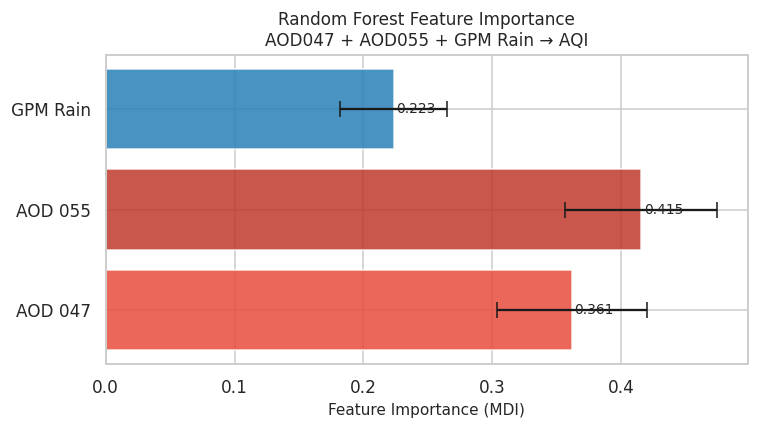


Feature importances:
  AOD 047        : 0.3614 ± 0.0581
  AOD 055        : 0.4153 ± 0.0591
  GPM Rain       : 0.2233 ± 0.0414


In [27]:
# ── Random Forest Feature Importance ─────────────────────────────────────
all_feats = ['Optical_Depth_047', 'Optical_Depth_055', 'total_accum_day']
feat_labels = ['AOD 047', 'AOD 055', 'GPM Rain']

X_all = complete[all_feats].values
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_all, y)

importances = rf.feature_importances_
std_imp = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(feat_labels, importances, xerr=std_imp, capsize=5,
               color=['#E74C3C', '#C0392B', '#2980B9'], alpha=0.85)
ax.set_xlabel('Feature Importance (MDI)', fontsize=10)
ax.set_title('Random Forest Feature Importance\n'
             'AOD047 + AOD055 + GPM Rain → AQI', fontsize=11)
for bar, imp in zip(bars, importances):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{imp:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\nFeature importances:")
for f, i in zip(feat_labels, importances):
    print(f"  {f:<15}: {i:.4f} ± {std_imp[feat_labels.index(f)]:.4f}")


## 16. Incremental Predictive Value of GPM — Partial R² and Δ R²

We quantify **exactly how much** AQI variance GPM explains beyond AOD alone.  
- **Δ R²**: increase in cross-validated R² when adding GPM to AOD  
- **Partial R²**: variance in AQI residuals (after removing AOD's contribution) explained by GPM

A meaningful Δ R² or partial R² confirms GPM as a useful complementary predictor.


In [28]:
# ── Δ R² table ─────────────────────────────────────────────────────────────
base_sets = {
    'AOD047':       ['Optical_Depth_047'],
    'AOD055':       ['Optical_Depth_055'],
    'AOD047+055':   ['Optical_Depth_047', 'Optical_Depth_055'],
}
aug_sets = {
    'AOD047+Rain':      ['Optical_Depth_047', 'total_accum_day'],
    'AOD055+Rain':      ['Optical_Depth_055', 'total_accum_day'],
    'AOD047+055+Rain':  ['Optical_Depth_047', 'Optical_Depth_055', 'total_accum_day'],
}

complete2 = df[['AQI', 'Optical_Depth_047', 'Optical_Depth_055', 'total_accum_day']].dropna()
y2 = complete2['AQI'].values

def cv_r2(feats):
    X = complete2[feats].values
    pipe = make_pipeline(StandardScaler(), LinearRegression())
    return cross_val_score(pipe, X, y2, cv=5, scoring='r2').mean()

rows_delta = []
for (bname, bfeats), (aname, afeats) in zip(base_sets.items(), aug_sets.items()):
    r2_base = cv_r2(bfeats)
    r2_aug  = cv_r2(afeats)
    rows_delta.append({
        'Base model':      bname,
        'Augmented model': aname,
        'R² (base)':       round(r2_base, 4),
        'R² (+GPM)':       round(r2_aug, 4),
        'Δ R²':            round(r2_aug - r2_base, 4),
    })

df_delta = pd.DataFrame(rows_delta)
print("Incremental R² from adding GPM to AOD-only models:")
print(df_delta.to_string(index=False))

# ── Partial R²: GPM→AQI | AOD047 ─────────────────────────────────────────
# Regress AQI on AOD047, get residuals, then regress residuals on GPM
from sklearn.linear_model import LinearRegression

X_aod = complete2[['Optical_Depth_047']].values
lr_aod = LinearRegression().fit(X_aod, y2)
resid_aod = y2 - lr_aod.predict(X_aod)

X_gpm = complete2[['total_accum_day']].values
lr_gpm = LinearRegression().fit(X_gpm, resid_aod)
partial_r2 = r2_score(resid_aod, lr_gpm.predict(X_gpm))

print(f"\nPartial R² of GPM → AQI residuals (after removing AOD047 contribution):")
print(f"  Partial R² = {partial_r2:.4f}")
print(f"  ({partial_r2*100:.1f}% of AOD's unexplained AQI variance is explained by GPM)")


Incremental R² from adding GPM to AOD-only models:
Base model Augmented model  R² (base)  R² (+GPM)    Δ R²
    AOD047     AOD047+Rain    -0.0922    -0.0914  0.0008
    AOD055     AOD055+Rain    -0.0806    -0.0804  0.0003
AOD047+055 AOD047+055+Rain    -0.0873    -0.0940 -0.0067

Partial R² of GPM → AQI residuals (after removing AOD047 contribution):
  Partial R² = 0.0031
  (0.3% of AOD's unexplained AQI variance is explained by GPM)


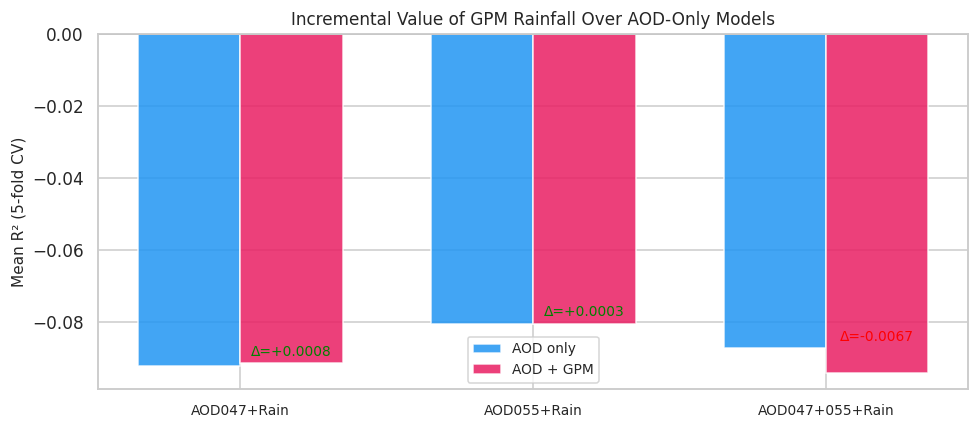

In [29]:
# ── Visual: Δ R² bar chart ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(df_delta))
w = 0.35
ax.bar(x - w/2, df_delta['R² (base)'], w, label='AOD only',  color='#2196F3', alpha=0.85)
ax.bar(x + w/2, df_delta['R² (+GPM)'], w, label='AOD + GPM', color='#E91E63', alpha=0.85)

for i, row in df_delta.iterrows():
    delta = row['Δ R²']
    ax.annotate(f'Δ={delta:+.4f}',
                xy=(i + w/2, max(row['R² (base)'], row['R² (+GPM)']) + 0.002),
                ha='center', fontsize=9,
                color='green' if delta > 0 else 'red')

ax.set_xticks(x)
ax.set_xticklabels(df_delta['Augmented model'], fontsize=9)
ax.set_ylabel('Mean R² (5-fold CV)', fontsize=10)
ax.set_title('Incremental Value of GPM Rainfall Over AOD-Only Models', fontsize=11)
ax.legend(fontsize=9)
ax.axhline(0, color='gray', lw=0.6)
plt.tight_layout()
plt.show()


## 17. Spatial Overview — Station Correlations on a Map

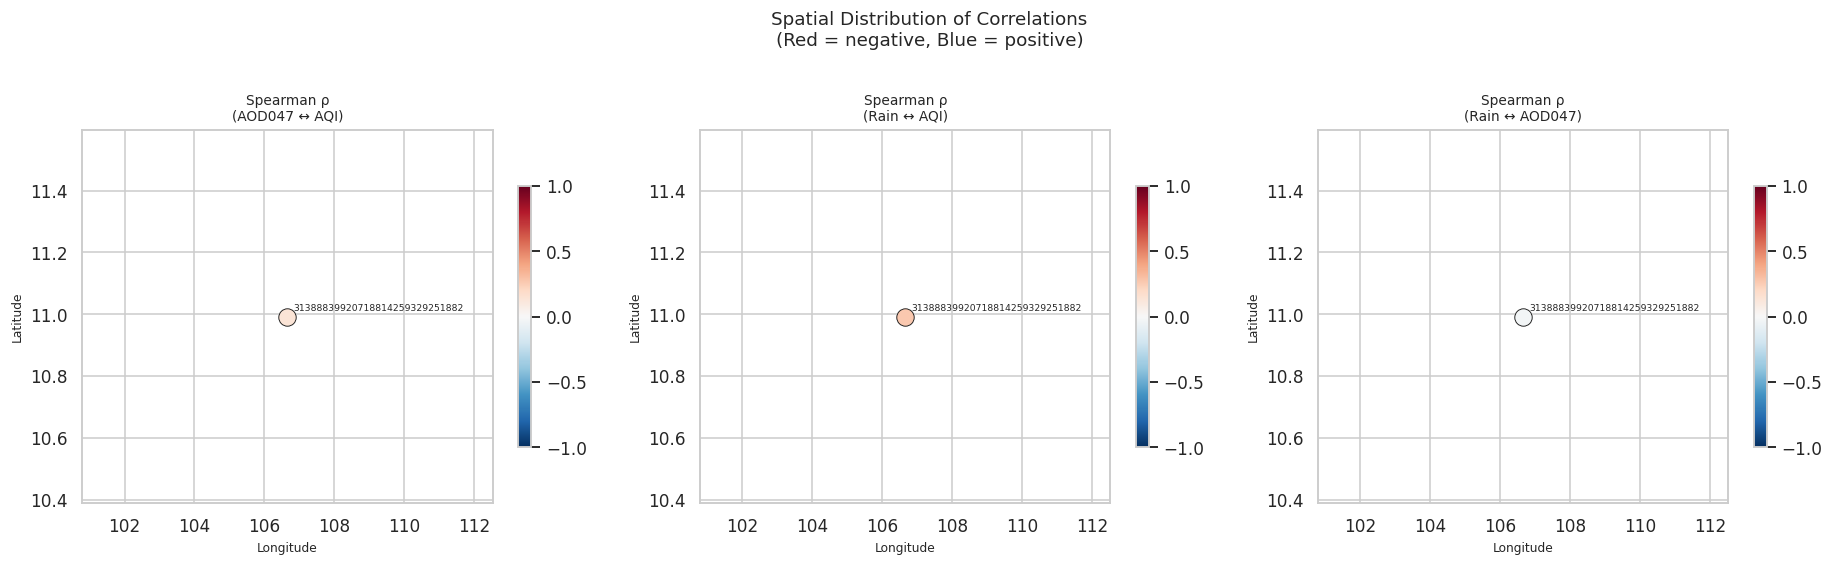

In [30]:
map_df = df_station_corr.merge(meta_coords, on='station_id', how='left').dropna(subset=['lat', 'lon'])

if len(map_df) == 0:
    print("No coordinate data available for mapping — skipping.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    for ax, col, label in zip(
        axes,
        ['r_AOD047_AQI', 'r_rain_AQI', 'r_rain_AOD047'],
        ['Spearman ρ\n(AOD047 ↔ AQI)',
         'Spearman ρ\n(Rain ↔ AQI)',
         'Spearman ρ\n(Rain ↔ AOD047)']
    ):
        sc = ax.scatter(map_df['lon'], map_df['lat'],
                        c=map_df[col], cmap='RdBu_r',
                        vmin=-1, vmax=1, s=130, edgecolors='k', lw=0.6)
        plt.colorbar(sc, ax=ax, shrink=0.7)
        for _, row in map_df.iterrows():
            ax.annotate(str(row['station_id']),
                        (row['lon'], row['lat']),
                        fontsize=6, xytext=(4, 4),
                        textcoords='offset points')
        ax.set_xlabel('Longitude', fontsize=8)
        ax.set_ylabel('Latitude', fontsize=8)
        ax.set_title(label, fontsize=9)

    plt.suptitle('Spatial Distribution of Correlations\n'
                 '(Red = negative, Blue = positive)', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()


## 18. Time Series Analysis — GPM, AQI, and AOD Co-evolution

For each station we plot the full time series with:
- **GPM rainfall** as shaded bars (primary axis)
- **AQI** and **AOD** as lines (dual axis)
- **7-day rolling averages** to reveal the washout signal through short-term noise
- **Rain event markers** (vertical dashed lines) at days with > 10 mm to visually verify  
  the expected delayed suppression in AQI/AOD


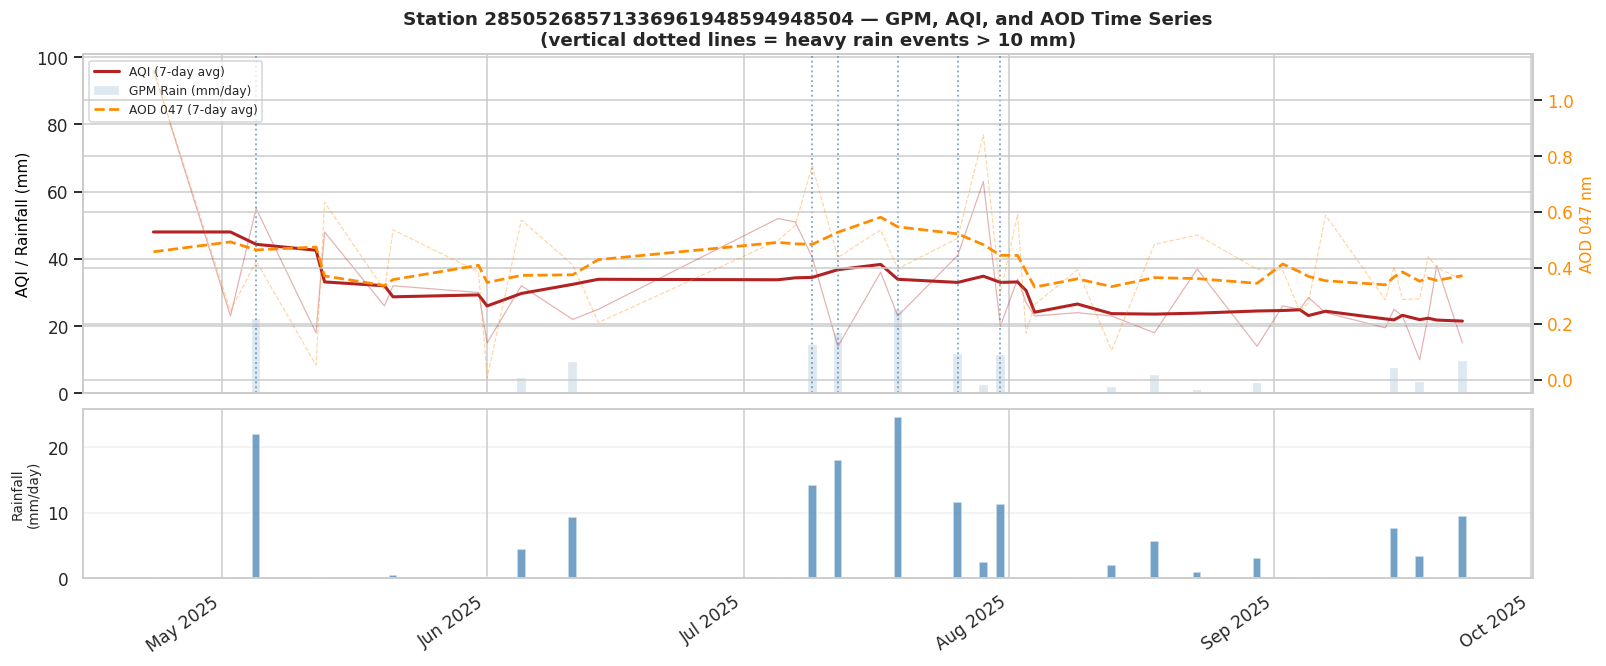

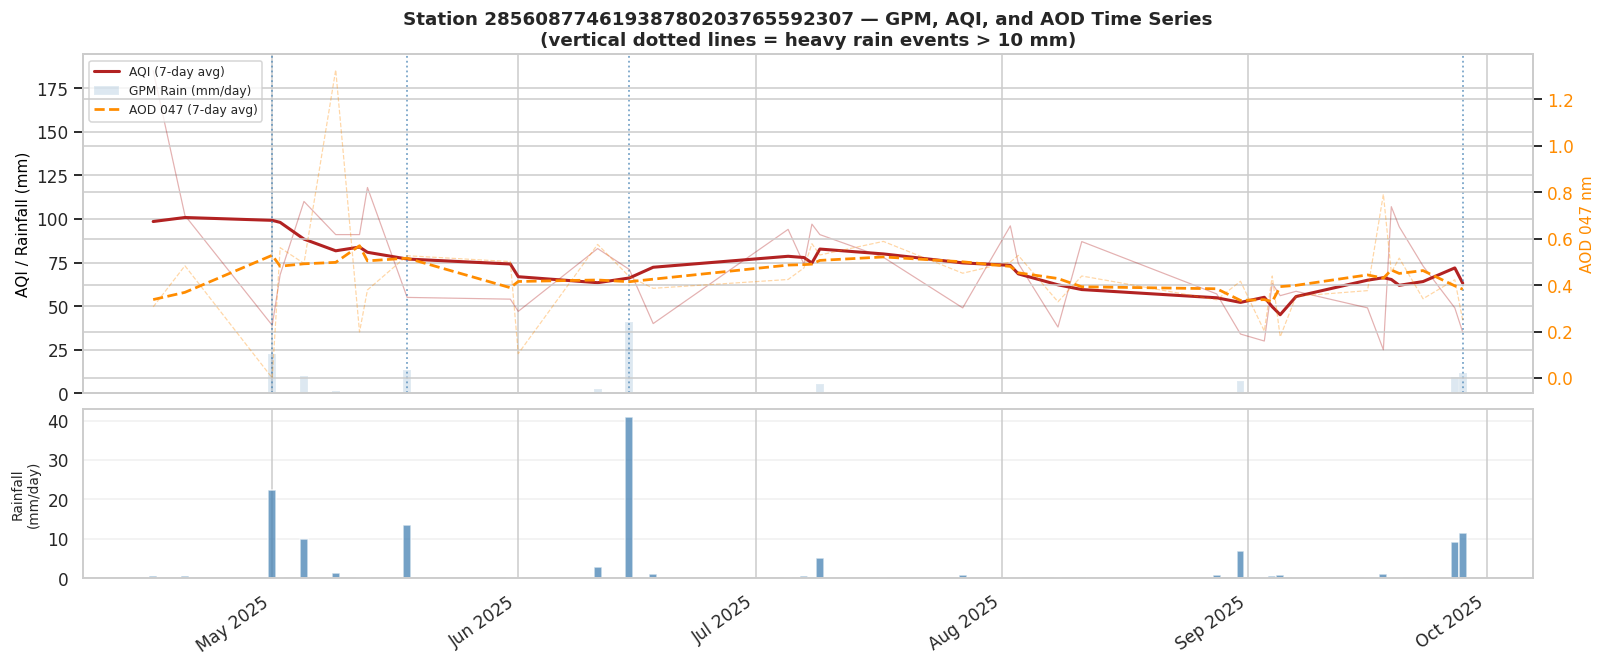

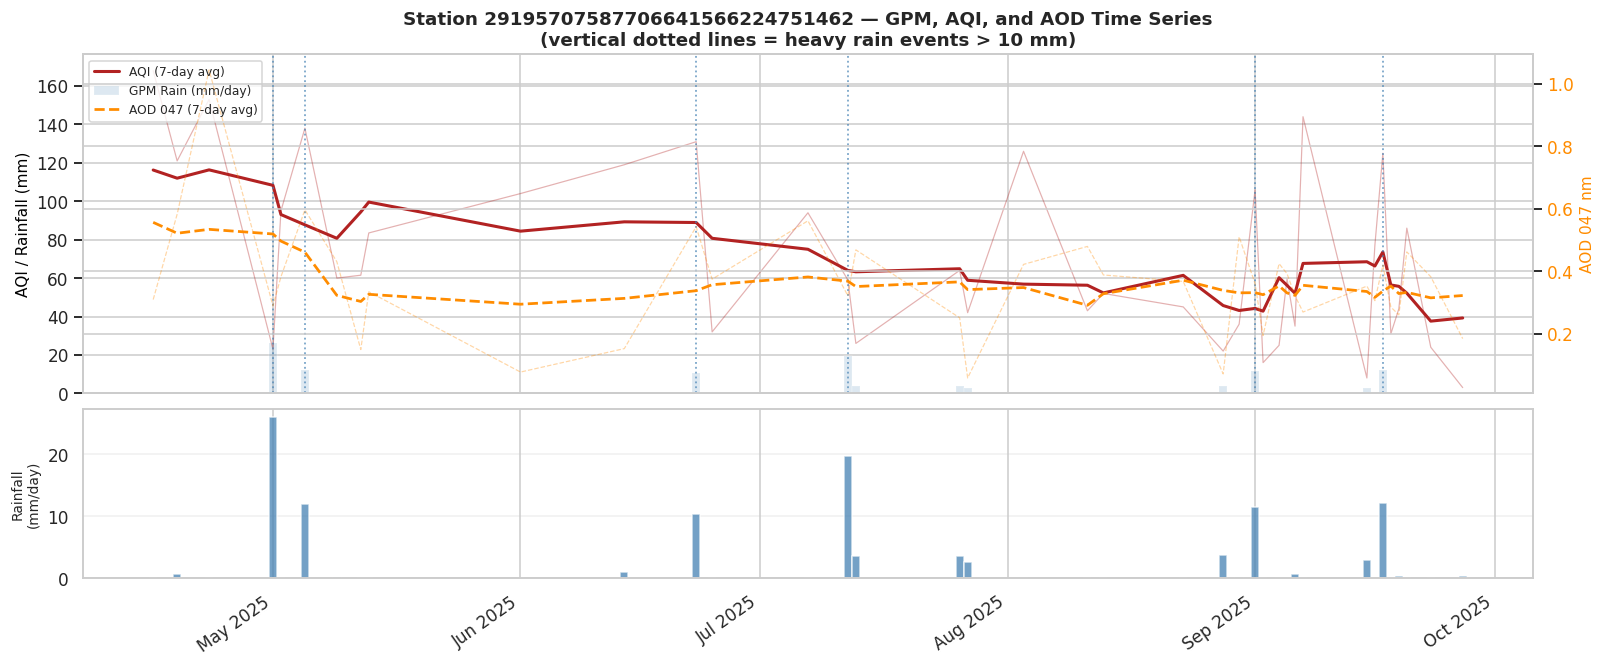

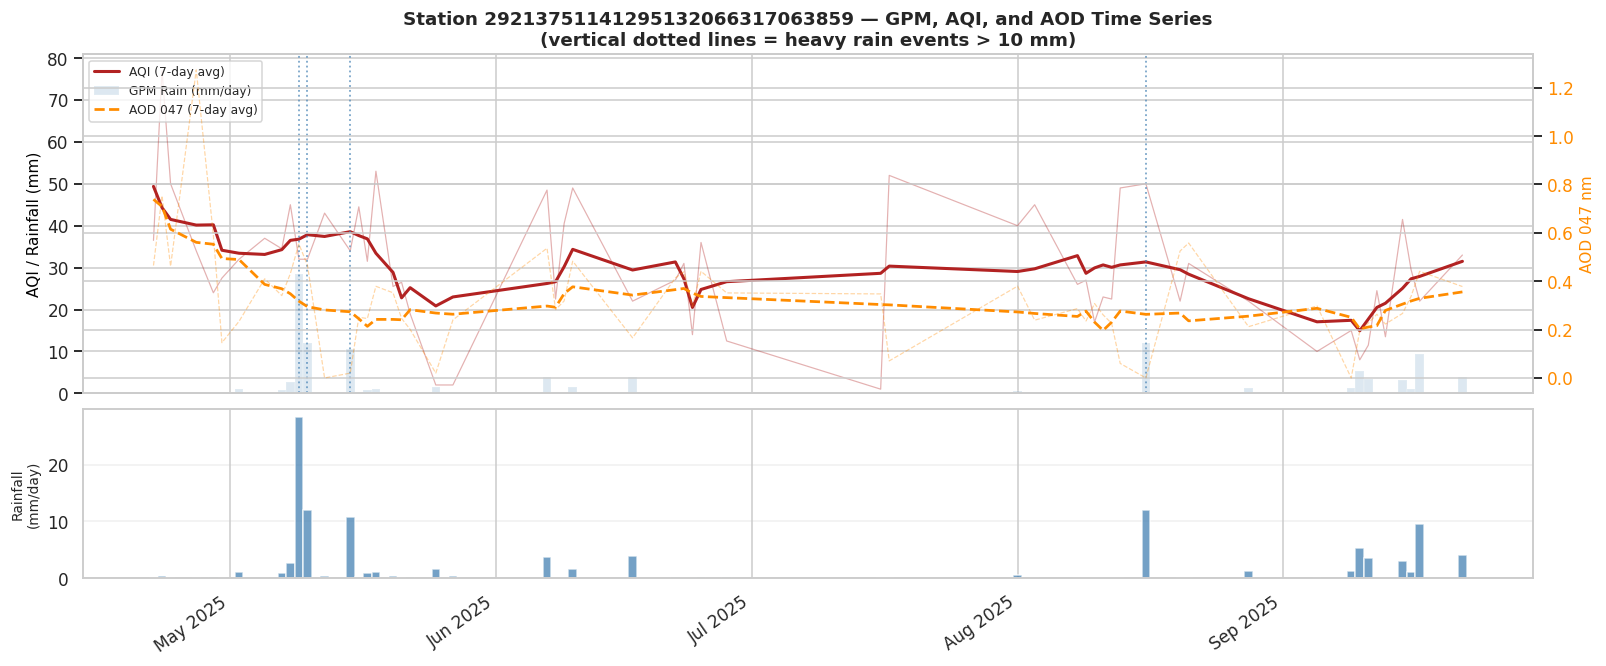

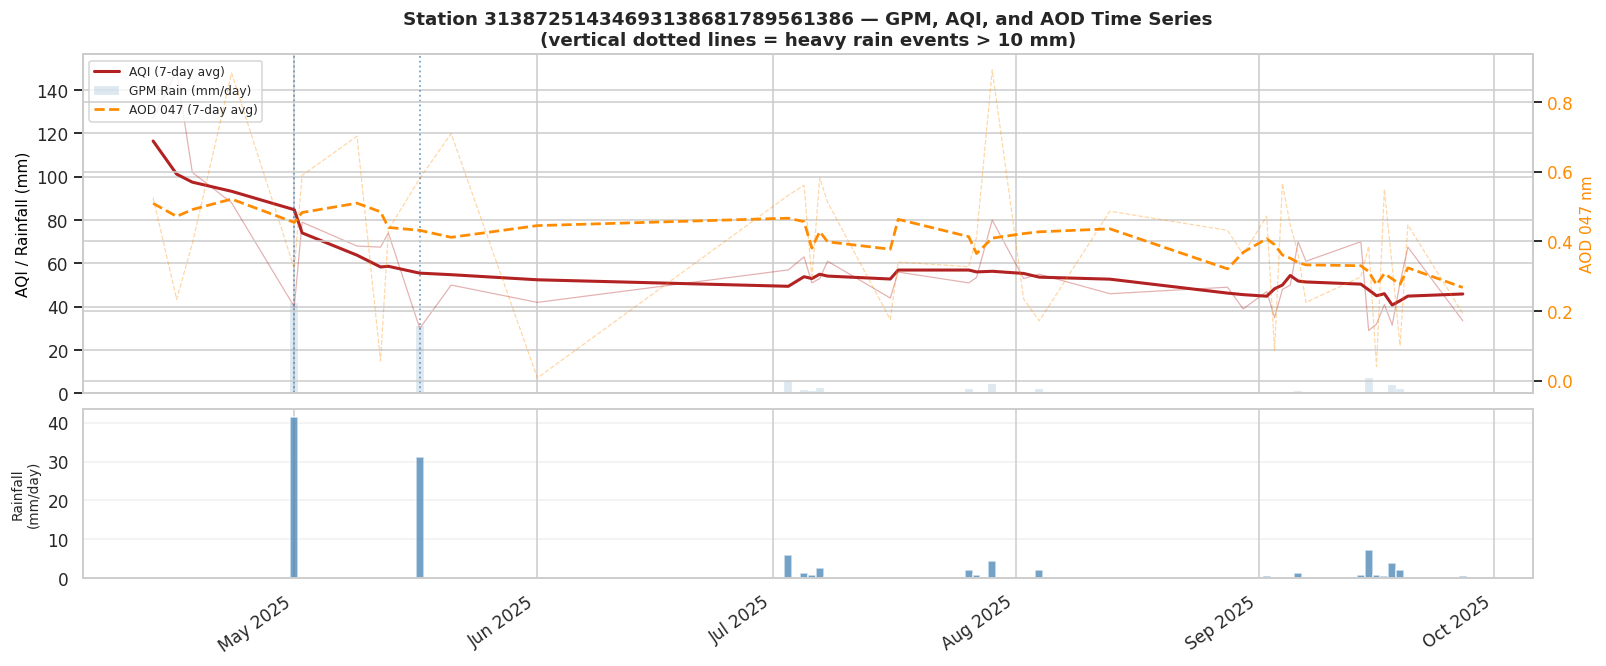

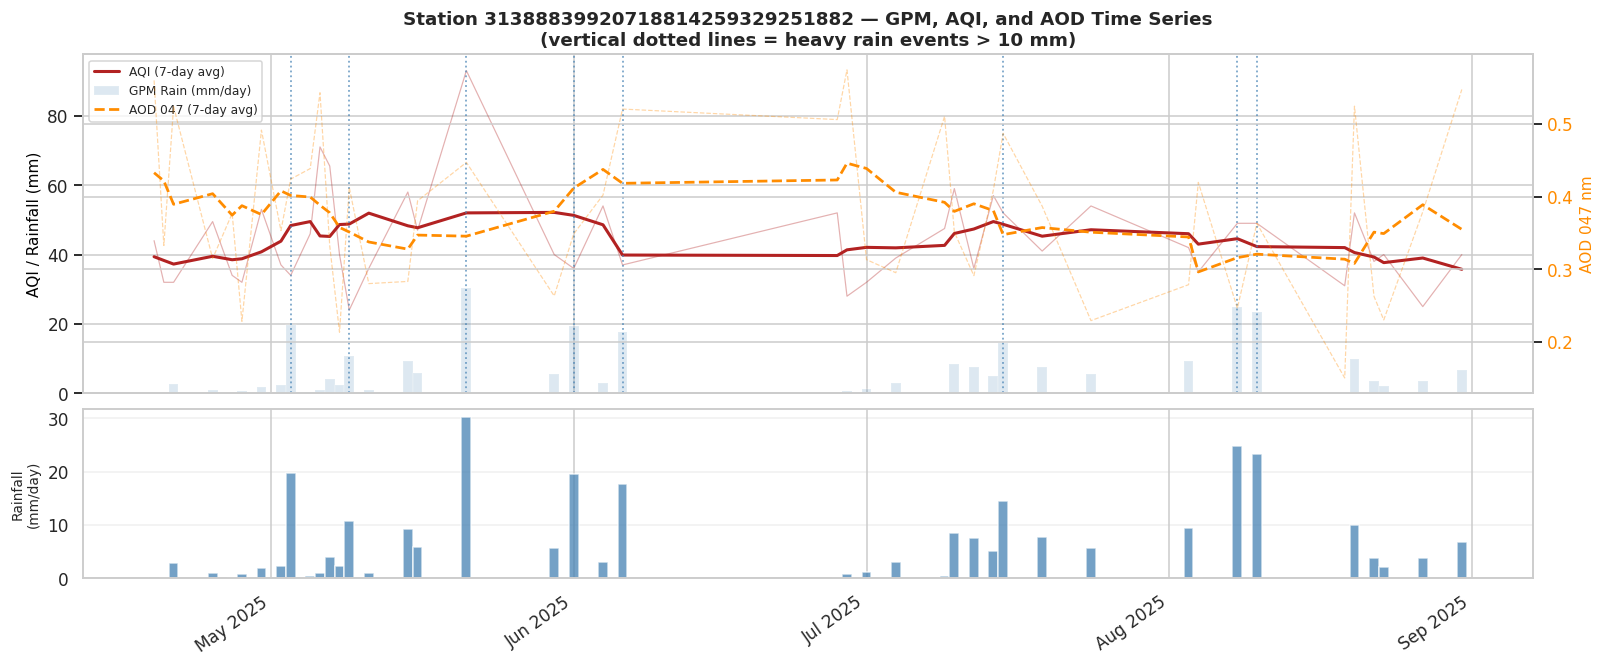

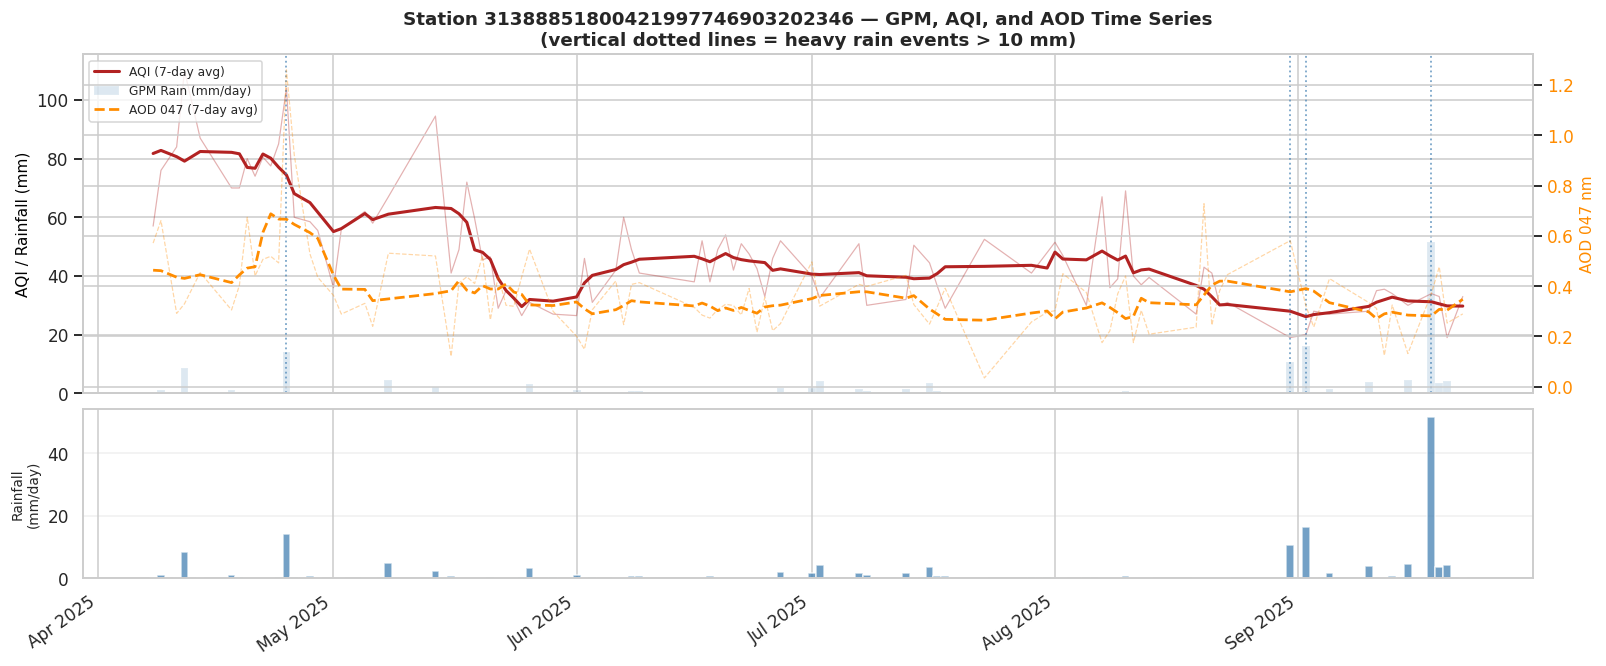

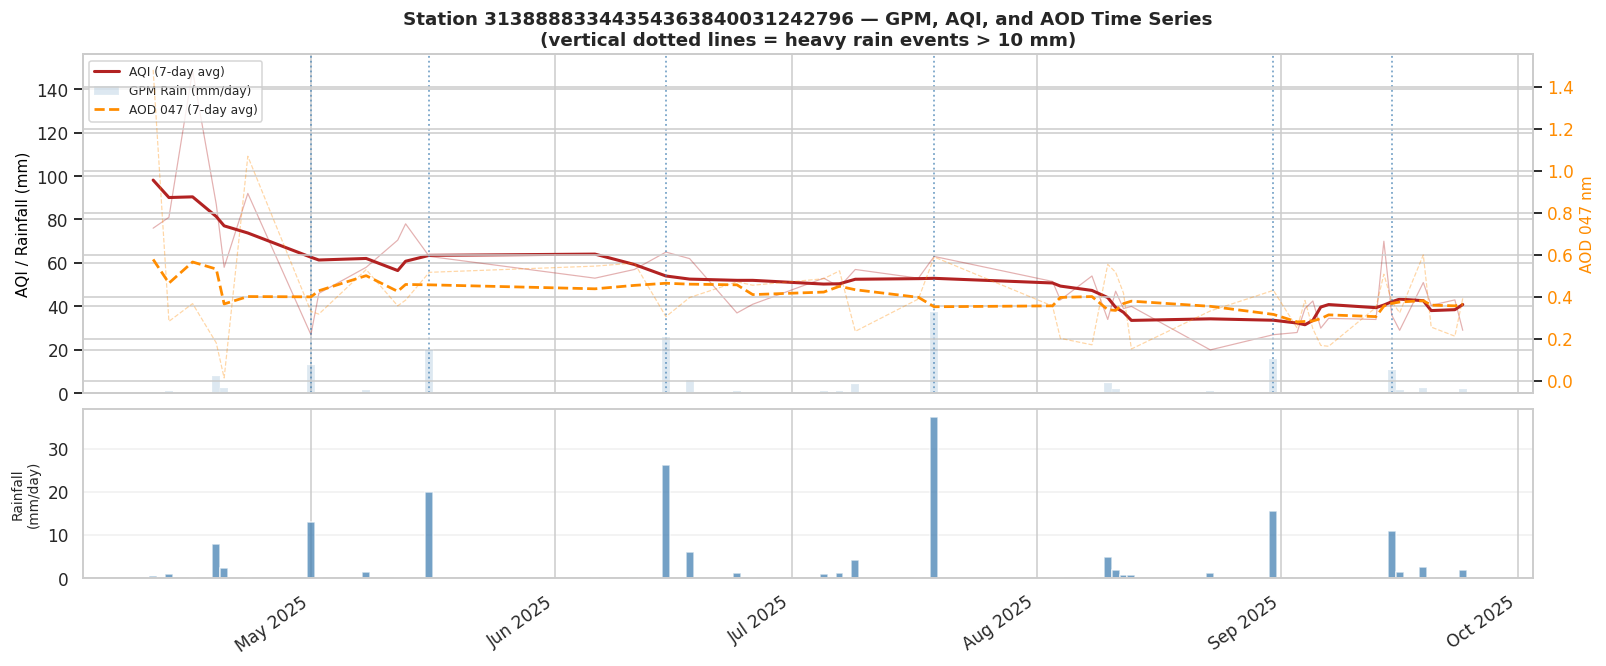

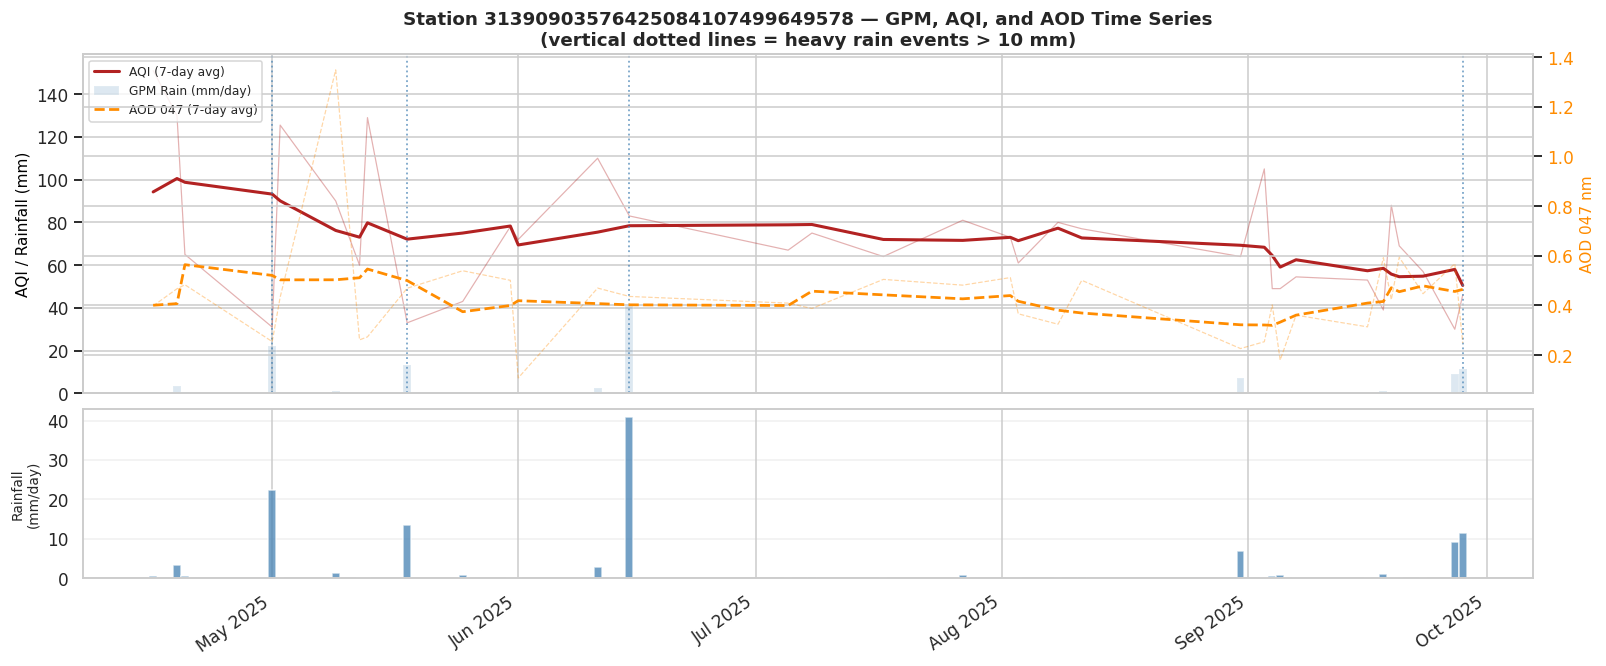

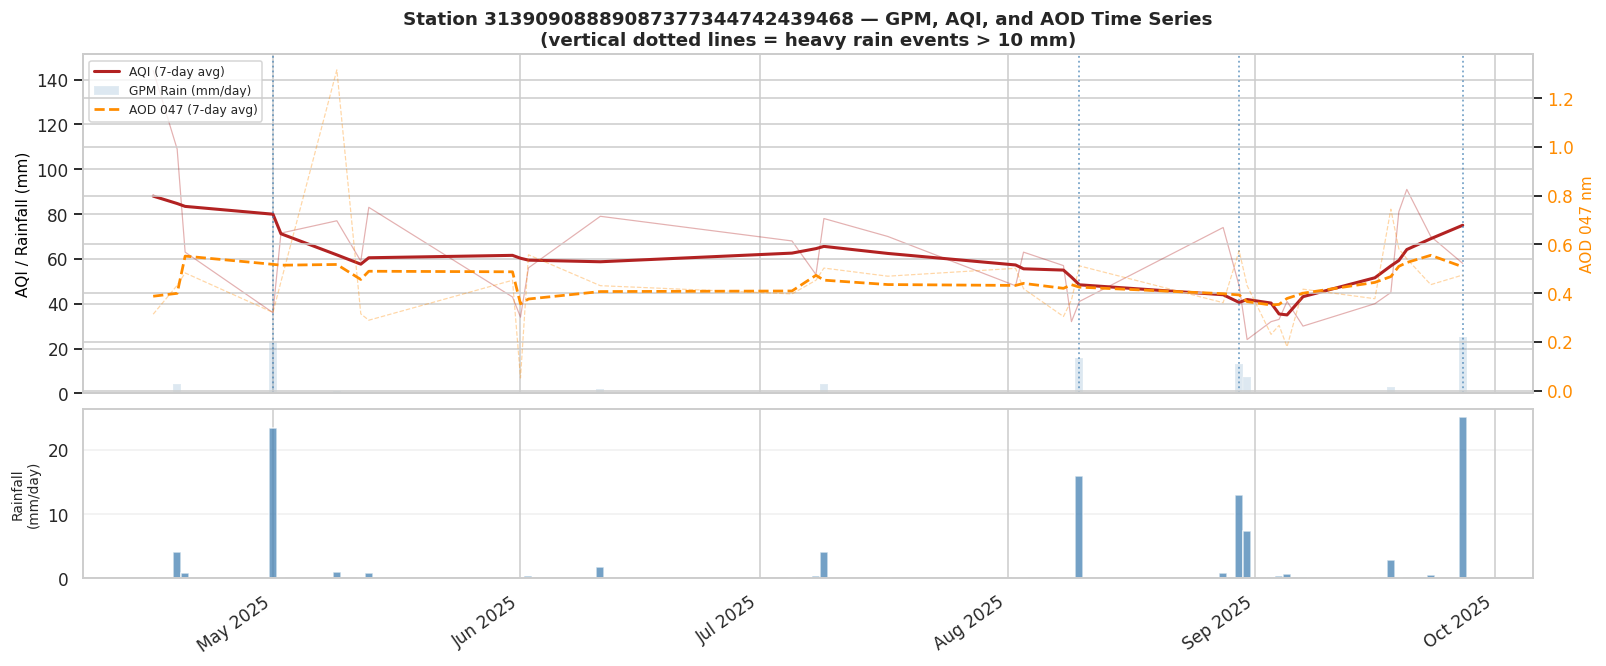

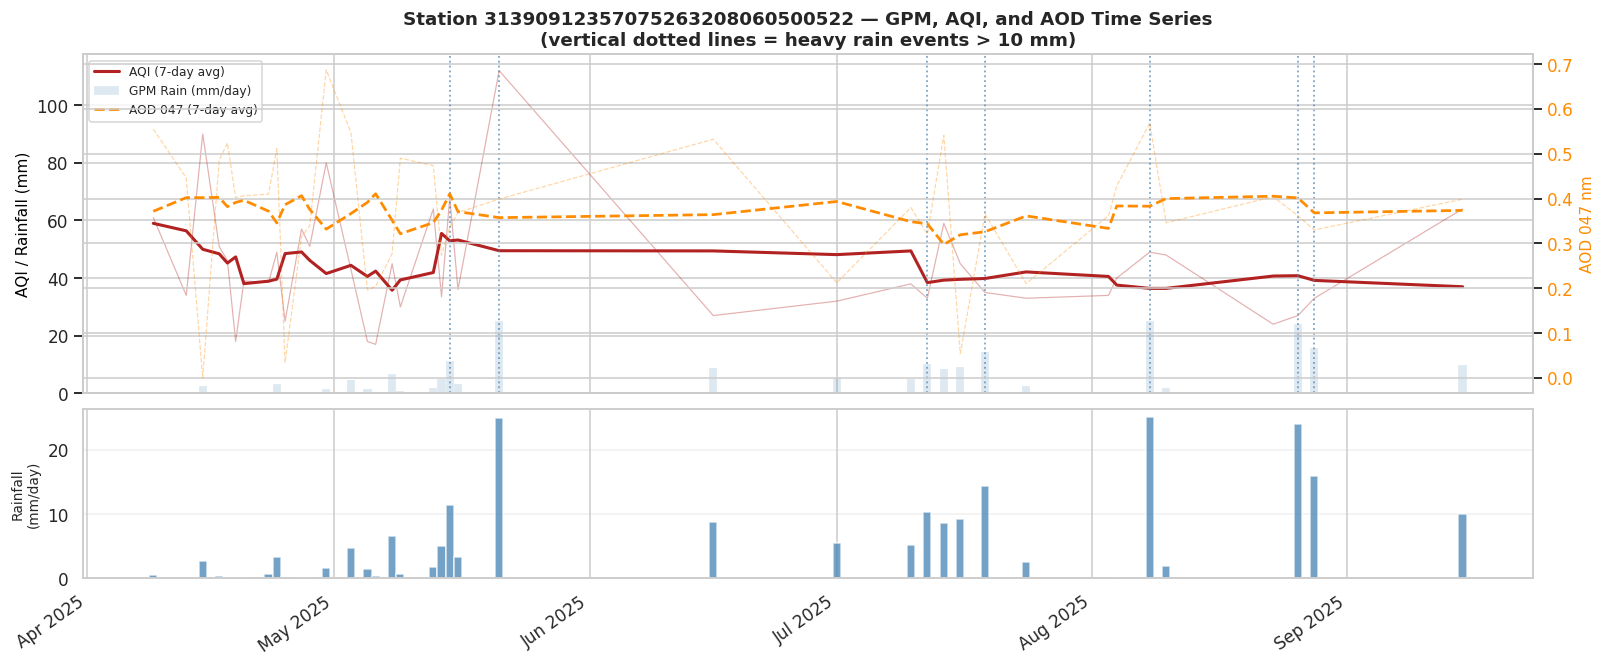

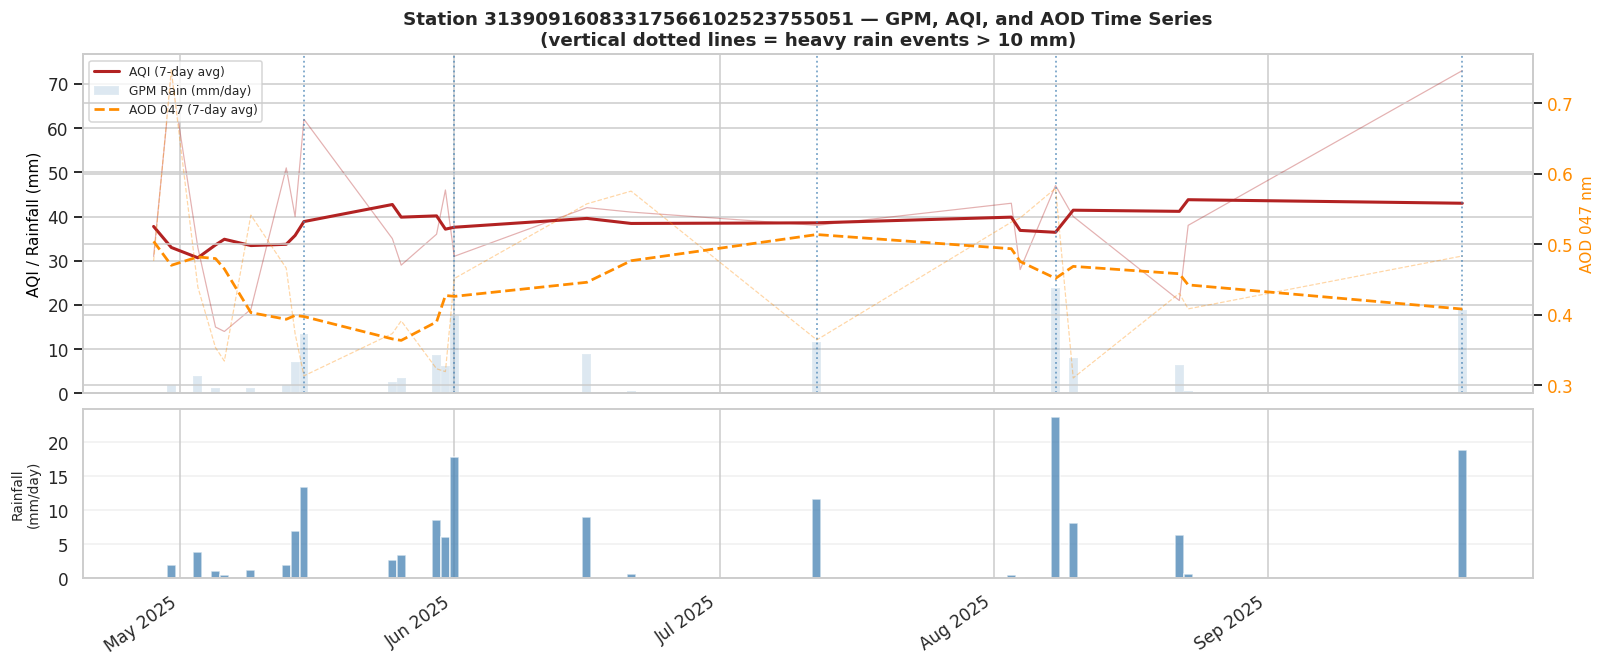

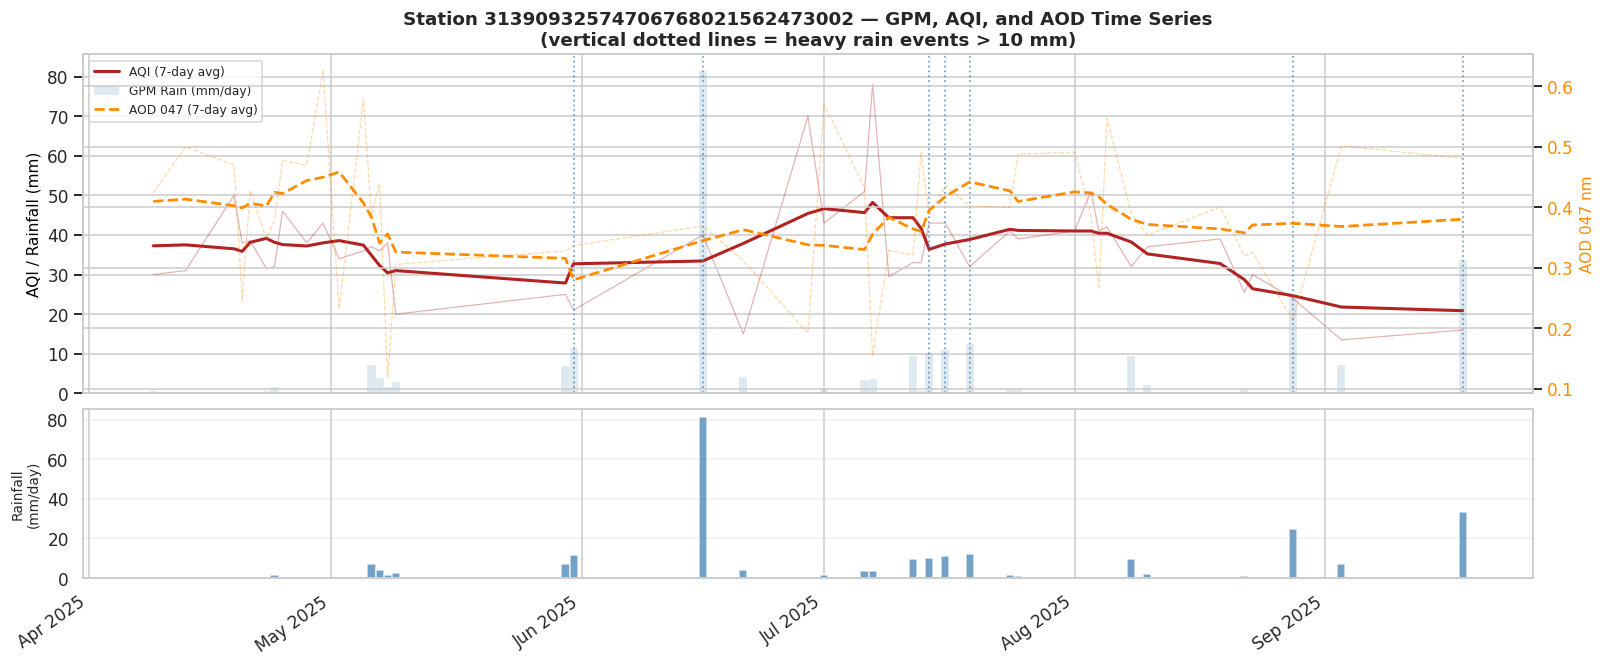

In [31]:
df['date'] = pd.to_datetime(df['date'])

for station_id, group in df.groupby('station_id'):
    group = group.sort_values('date').copy()

    # 7-day rolling averages
    group['AQI_7d']  = group['AQI'].rolling(7, min_periods=3, center=True).mean()
    group['AOD_7d']  = group['Optical_Depth_047'].rolling(7, min_periods=3, center=True).mean()

    # Identify heavy rain event days (> 10 mm)
    rain_events = group.loc[group['total_accum_day'] > 10, 'date']

    fig = plt.figure(figsize=(17, 7))
    gs  = gridspec.GridSpec(2, 1, height_ratios=[2, 1], hspace=0.06)

    # ── Panel 1: AQI + AOD ───────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0])
    ax2 = ax1.twinx()

    # GPM bars on background
    ax1.bar(group['date'], group['total_accum_day'],
            color='steelblue', alpha=0.18, width=1, label='GPM Rain (mm/day)')

    # AQI raw + rolling
    ax1.plot(group['date'], group['AQI'], color='firebrick', lw=0.8, alpha=0.35)
    ax1.plot(group['date'], group['AQI_7d'], color='firebrick', lw=2.0, label='AQI (7-day avg)')

    # AOD on secondary axis
    ax2.plot(group['date'], group['Optical_Depth_047'], color='darkorange',
             lw=0.8, alpha=0.35, ls='--')
    ax2.plot(group['date'], group['AOD_7d'], color='darkorange',
             lw=1.8, ls='--', label='AOD 047 (7-day avg)')

    # Mark heavy rain events
    for ev_date in rain_events:
        ax1.axvline(ev_date, color='steelblue', lw=1.2, ls=':', alpha=0.7)

    ax1.set_ylabel('AQI / Rainfall (mm)', fontsize=10, color='black')
    ax2.set_ylabel('AOD 047 nm', fontsize=10, color='darkorange')
    ax2.tick_params(axis='y', labelcolor='darkorange')
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax1.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax1.xaxis.get_majorticklabels(), visible=False)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)
    ax1.set_title(f'Station {station_id} — GPM, AQI, and AOD Time Series\n'
                  '(vertical dotted lines = heavy rain events > 10 mm)',
                  fontsize=12, fontweight='bold')

    # ── Panel 2: GPM bar chart ───────────────────────────────────────────
    ax3 = fig.add_subplot(gs[1], sharex=ax1)
    ax3.bar(group['date'], group['total_accum_day'],
            color='steelblue', alpha=0.75, width=1)
    ax3.set_ylabel('Rainfall\n(mm/day)', fontsize=9)
    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax3.xaxis.set_major_locator(mdates.MonthLocator())
    fig.autofmt_xdate(rotation=35, ha='right')
    ax3.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()


## 19. Summary & Conclusions

| Finding | Evidence | Implication |
|---------|----------|-------------|
| AOD→AQI RANSAC shows poor fit | Low R² in Section 8, high outlier fraction | AOD alone is insufficient for AQI prediction |
| GPM negatively correlates with AQI on rainy days | Kruskal-Wallis, Spearman ρ < 0 | Rain suppresses particulate matter (wet scavenging) |
| AOD RANSAC residuals correlate with GPM | Residual analysis (Section 10) | GPM captures variance AOD misses |
| Optimal rain-to-AQI lag is 0–2 days | Lead-lag cross-correlation (Section 13) | Use same-day + lagged GPM as features |
| Adding GPM improves linear R² | Δ R² in Section 16 | GPM is a statistically complementary predictor |
| Random Forest assigns meaningful importance to GPM | Feature importance (Section 15) | Non-linear rain effects exist |
| Station-level variability is high | Per-station heatmap (Section 14) | GPM effect is stronger at some stations — consider stratified models |

### Recommendation
> Given the consistently poor AOD→AQI RANSAC fit and the evidence that GPM captures  
> orthogonal variance (non-zero partial R², Δ R², residual correlation), **GPM rainfall  
> should be included as a feature in AQI prediction models** — ideally with same-day and  
> 1–2 day lagged values. The improvement is modest in linear models but more pronounced  
> in non-linear models (Random Forest), suggesting the rain-AQI relationship is threshold-driven.


## 20. Save Results

In [32]:
out_dir = Path(MODIS_AQI_DIR)

df_station_corr.to_csv(out_dir / "aod_aqi_gpm_station_correlations.csv", index=False)
df.to_csv(out_dir / "aod_aqi_gpm_merged_daily.csv", index=False)
df_lag.to_csv(out_dir / "aod_aqi_gpm_lag_correlations.csv", index=False)
df_delta.to_csv(out_dir / "gpm_incremental_r2.csv", index=False)
sub047[['total_accum_day', 'AQI', 'residual', 'inlier', 'rain_bin']].to_csv(
    out_dir / "ransac_aod_residuals_vs_gpm.csv", index=False)

print("Saved:")
for f in ["aod_aqi_gpm_station_correlations.csv",
          "aod_aqi_gpm_merged_daily.csv",
          "aod_aqi_gpm_lag_correlations.csv",
          "gpm_incremental_r2.csv",
          "ransac_aod_residuals_vs_gpm.csv"]:
    print(f"  {out_dir / f}")


Saved:
  /home/slow_data/Air_Quality/MODIS_MCD19A2/stations_aod_v2/aod_aqi_gpm_station_correlations.csv
  /home/slow_data/Air_Quality/MODIS_MCD19A2/stations_aod_v2/aod_aqi_gpm_merged_daily.csv
  /home/slow_data/Air_Quality/MODIS_MCD19A2/stations_aod_v2/aod_aqi_gpm_lag_correlations.csv
  /home/slow_data/Air_Quality/MODIS_MCD19A2/stations_aod_v2/gpm_incremental_r2.csv
  /home/slow_data/Air_Quality/MODIS_MCD19A2/stations_aod_v2/ransac_aod_residuals_vs_gpm.csv
